## Phase1: Installation and Introduction

In [19]:
# ============================================================
# Installation
# ============================================================

%pip install torch numpy matplotlib networkx

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import csv
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Device: {device}")
print(f"   PyTorch: {torch.__version__}")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
✅ Device: cpu
   PyTorch: 2.10.0+cpu


In [20]:
# ============================================================
# Graph Construction: COCO 17-Keypoint Skeleton
# ============================================================
#
# ■ COCO 17-Keypoint skelton construction:
#
# YOLO26 outputs 17 keypoints in COCO format.
# By defining the "bone" connections between these keypoints, the graph is complete.
#
# ■ Meaning of adjacency matrix A:
#   A is an N×N matrix (N=17)
#   A[i][j] = 1 → node i and j are connected by a bone
#   A[i][j] = 0 → not connected
#
#   Example: A[5][7] = 1 → left_shoulder(5) and left_elbow(7) are connected
#
# ■ Why add self-loops (A[i][i] = 1)?
#   In the GCN update formula, self-loops ensure that each node retains
#   its own features during aggregation.
#   Without self-loops, a node's own information would be lost after each update.

KEYPOINT_NAMES = [
    'nose',           # 0
    'left_eye',       # 1
    'right_eye',      # 2
    'left_ear',       # 3
    'right_ear',      # 4
    'left_shoulder',  # 5
    'right_shoulder', # 6
    'left_elbow',     # 7
    'right_elbow',    # 8
    'left_wrist',     # 9
    'right_wrist',    # 10
    'left_hip',       # 11
    'right_hip',      # 12
    'left_knee',      # 13
    'right_knee',     # 14
    'left_ankle',     # 15
    'right_ankle',    # 16
]
NUM_KEYPOINTS = len(KEYPOINT_NAMES)

# Define the edges based on COCO skeleton
#Each tuple (i, j) represents a connected joints between keypoint i and j
SKELETON_EDGES = [
    # Head connections
    (0, 1),   # nose - left_eye
    (0, 2),   # nose - right_eye
    (1, 3),   # left_eye - left_ear
    (2, 4),   # right_eye - right_ear
    # Upper body
    (5, 6),   # left_shoulder - right_shoulder
    (5, 7),   # left_shoulder - left_elbow
    (7, 9),   # left_elbow - left_wrist
    (6, 8),   # right_shoulder - right_elbow
    (8, 10),  # right_elbow - right_wrist
    # Core connections
    (5, 11),  # left_shoulder - left_hip
    (6, 12),  # right_shoulder - right_hip
    (11, 12), # left_hip - right_hip
    # Head-shoulder connections
    (0, 5),   # nose - left_shoulder (check)
    (0, 6),   # nose - right_shoulder
    # Lower body connections
    (11, 13), # left_hip - left_knee
    (13, 15), # left_knee - left_ankle
    (12, 14), # right_hip - right_knee
    (14, 16), # right_knee - right_ankle
]

# Create adjacency matrix A
def build_adjacency_matrix(num_nodes, edges, add_self_loops=True):
    """
    Build adjacency matrix A from skeleton connection list.
    
    ■ Mathematical meaning:
      A ∈ R^{N×N}, A[i][j] = 1 if (i,j) ∈ E
      Since it is an undirected graph, A is a symmetric matrix: A = A^T
    
    ■ Adding Self-loops:
      A_hat = A + I (I = identity matrix)
      → To retain each node's own features during GCN updates
    
    Parameters:
        num_nodes: Number of nodes (17)
        edges: List of edges [(i, j), ...]
        add_self_loops: Whether to add self-loops
    
    Returns:
        A: Adjacency matrix (numpy array, shape [N, N])
    """
    
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    for i, j in edges:
        A[i][j] = 1
        A[j][i] = 1  # Undirected graph
    if add_self_loops:
        A = A + np.eye(num_nodes, dtype=np.float32)  # A_hat = A + I 
    return A

A = build_adjacency_matrix(NUM_KEYPOINTS, SKELETON_EDGES, add_self_loops=True)
print("✅ Adjacency matrix A (with self-loops):")
print(f"  A.shape: {A.shape}")
print(f"  Edge numbers {len(SKELETON_EDGES)} (without self-loops)")
print(f"  {np.allclose(A, A.T)} (A is symmetric: undirected graph)")

print(f"  A[5][7] (left_shoulder - left_elbow): {A[5][7]} (connected)")
print(f"  A[5][16] (left_shoulder - right_ankle): {A[5][16]} (not connected)")
print(f"  A[5][5] (left_shoulder self-loop): {A[5][5]} (self-loop)")

✅ Adjacency matrix A (with self-loops):
  A.shape: (17, 17)
  Edge numbers 18 (without self-loops)
  True (A is symmetric: undirected graph)
  A[5][7] (left_shoulder - left_elbow): 1.0 (connected)
  A[5][16] (left_shoulder - right_ankle): 0.0 (not connected)
  A[5][5] (left_shoulder self-loop): 1.0 (self-loop)


In [21]:
# ============================================================
# Cell 3: ★★★ Step 1-b: Normalized Adjacency Matrix D^{-1/2} A D^{-1/2} ★★★
# ============================================================
#
# ■ Why is normalization necessary?
#
# The GCN update formula is:
#   h_i^{new} = σ( Σ_{j∈N(i)} A_ij * W * h_j )
#
# Problem: Each node has a different number of neighboring nodes (degree d)
#   Shoulder: 4 neighboring nodes (elbow, neck, hip, opposite shoulder) → sum of 4 values
#   Wrist: 1 neighboring node (elbow only) → only 1 value
#
# → Node features of high-degree nodes get "inflated"
#
# Solution: Normalization
#   A_norm = D^{-1/2} * A * D^{-1/2}
#   D = degree matrix (diagonal matrix where D_ii = Σ_j A_ij)
#
# Intuitive meaning:
#   "When summing neighbor information, divide by the square root of the degree to average"
#   → Both high-degree and low-degree nodes are updated at the same scale

def normalize_adjacency(A):
    """
    Symmetric normalization: D^{-1/2} * A * D^{-1/2}
    
    This is the standard normalization proposed in the GCN paper by Kipf & Welling (2017).
    Corresponds to equation (5) in the attached paper (GCT, Dwivedi & Bresson):
      h_i^{l+1} = σ( Σ_j (1/√(d_i * d_j)) * W * h_j )
    
    Parameters:
        A: Adjacency matrix (numpy array, shape [N, N])
    
    Returns:
        A_norm: Normalized adjacency matrix
    """
    #Step1: Compute degree matrix D
    #D_ii = Σ_j A_ij; D is a diagonal matrix where each diagonal element D_ii is the degree of node i
    D = np.diag(A.sum(axis=1))  # D_ii = Σ_j A_ij
    
    # Step 2: Compute D^{-1/2} 
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D) + 1e-8))  # D^{-1/2}
    
    #Step3: D^{-1/2} * A * D^{-1/2}
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt                 # D^{-1/2} A D^{-1/2}
    return A_norm

A_norm = normalize_adjacency(A)
print("✅ Normalized adjacency matrix A_norm:")
print(f"  Before normalization: A[5,7] = {A[5,7]:.4f} ")
print(f"  A_norm[5][7] (left_shoulder - left_elbow): {A_norm[5][7]:.3f}")
for i in [0, 5, 9, 14]:  # nose, l_shoulder, l_wrist, r_knee
    print(
        f"    {KEYPOINT_NAMES[i]:15s}: before normalization Σ={A[i].sum():.0f}, "
        f"after normalization Σ={A_norm[i].sum():.3f}"
    )
print("   → After normalization, the row sums of all nodes become close to 1.0")

✅ Normalized adjacency matrix A_norm:
  Before normalization: A[5,7] = 1.0000 
  A_norm[5][7] (left_shoulder - left_elbow): 0.258
    nose           : before normalization Σ=5, after normalization Σ=1.116
    left_shoulder  : before normalization Σ=5, after normalization Σ=1.082
    left_wrist     : before normalization Σ=2, after normalization Σ=0.908
    right_knee     : before normalization Σ=3, after normalization Σ=1.030
   → After normalization, the row sums of all nodes become close to 1.0


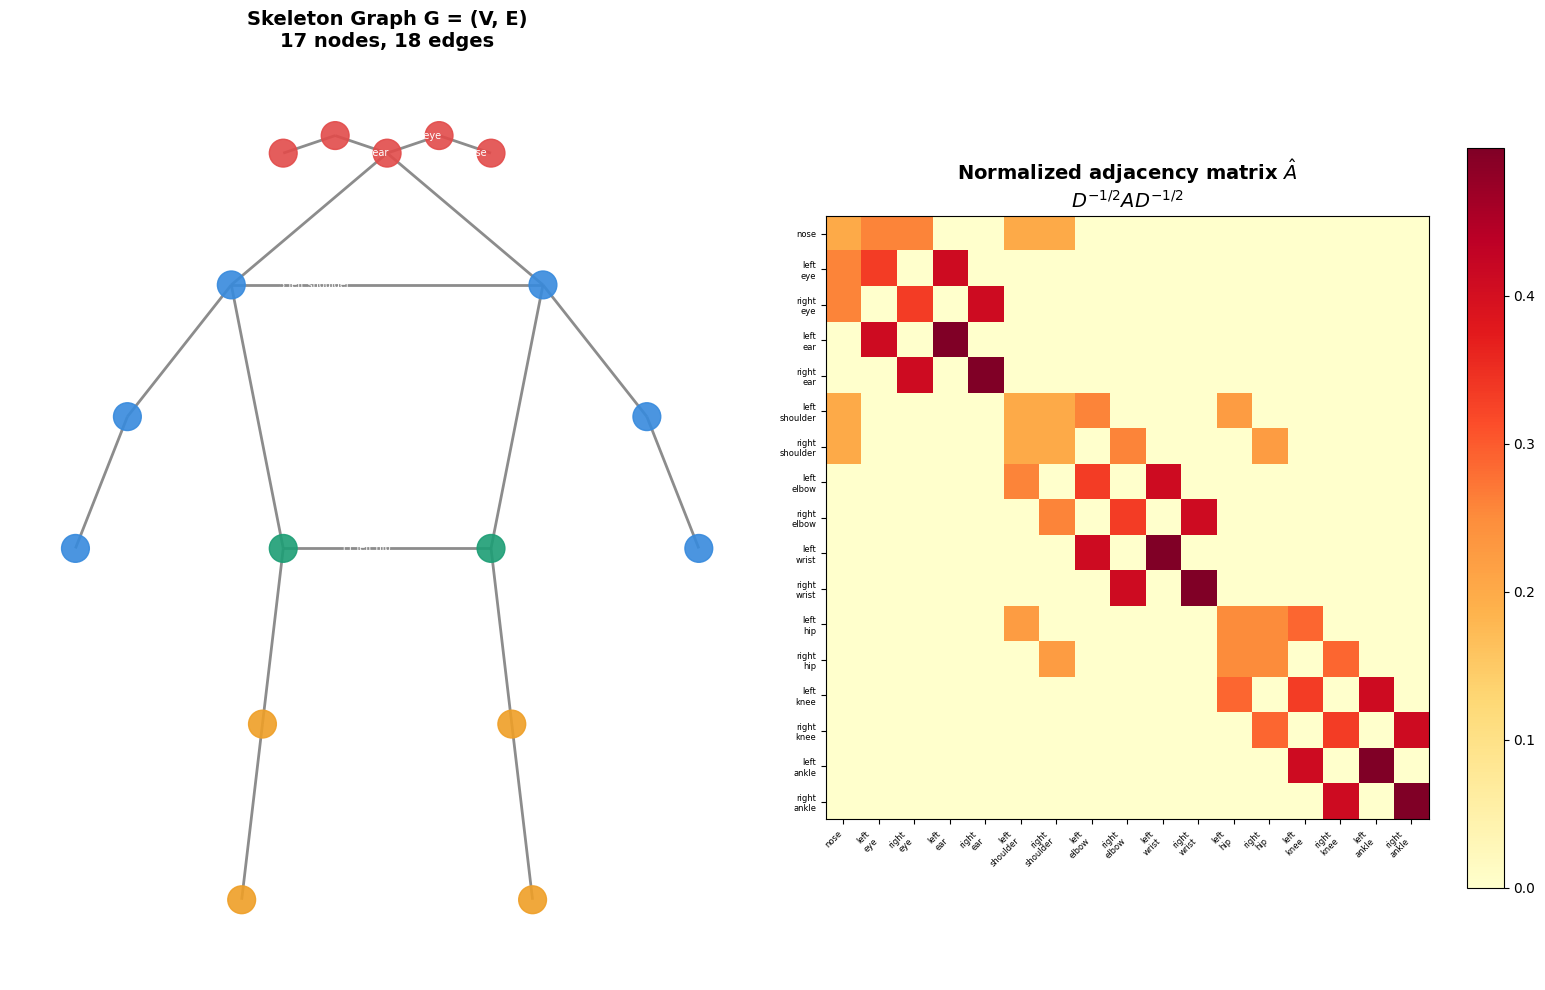

✅ Visualized the graph and adjacency matrix


In [ ]:
# ============================================================
# Graph Visualization
# ============================================================
#
# Use networkx to draw the graph in a layout close to actual human body positions.
# → This helps intuitively understand which nodes exchange information in the GCN.

# Body-mimicking layout for visualization (x, y) coordinates for each keypoint
BODY_LAYOUT = {
    0: (0.5, 1.0),     # nose
    1: (0.45, 1.02),   # left_eye
    2: (0.55, 1.02),   # right_eye
    3: (0.40, 1.0),    # left_ear
    4: (0.60, 1.0),    # right_ear
    5: (0.35, 0.85),   # left_shoulder
    6: (0.65, 0.85),   # right_shoulder
    7: (0.25, 0.70),   # left_elbow
    8: (0.75, 0.70),   # right_elbow
    9: (0.20, 0.55),   # left_wrist
    10: (0.80, 0.55),  # right_wrist
    11: (0.40, 0.55),  # left_hip
    12: (0.60, 0.55),  # right_hip
    13: (0.38, 0.35),  # left_knee
    14: (0.62, 0.35),  # right_knee
    15: (0.36, 0.15),  # left_ankle
    16: (0.64, 0.15),  # right_ankle
}


fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# --- Left: Graph structure ---
ax1 = axes[0]
G = nx.Graph()
for i, name in enumerate(KEYPOINT_NAMES):
    G.add_node(i, label=name)
for i, j in SKELETON_EDGES:
    G.add_edge(i, j)


# Node colors: color by body part
node_colors = []
for i in range(NUM_KEYPOINTS):
    if i <= 4:       node_colors.append('#E24B4A')   # Head: red
    elif i <= 10:    node_colors.append('#378ADD')   # Upper limbs: blue
    elif i <= 12:    node_colors.append('#1D9E75')   # Hip/core: green
    else:            node_colors.append('#EF9F27')   # Lower limbs: yellow

nx.draw(G, pos=BODY_LAYOUT, ax=ax1,
        with_labels=False, node_color=node_colors,
        node_size=400, width=2, edge_color='gray', alpha=0.9)

# Labels (slightly offset)
label_pos = {k: (v[0] + 0.08, v[1]) for k, v in BODY_LAYOUT.items()}
labels = {i: f"{i}:{name.replace('_', ' ')}" for i, name in enumerate(KEYPOINT_NAMES)}
nx.draw_networkx_labels(G, pos=label_pos, labels=labels, ax=ax1,
                        font_size=7, font_color='white')

ax1.set_title('Skeleton Graph G = (V, E)\n17 nodes, 18 edges', fontsize=14, fontweight='bold')
ax1.set_facecolor('#1a1a2e')

# --- Right: adjacency matrix heatmap ---
ax2 = axes[1]
im = ax2.imshow(A_norm, cmap='YlOrRd', aspect='equal')
ax2.set_xticks(range(NUM_KEYPOINTS))
ax2.set_yticks(range(NUM_KEYPOINTS))
ax2.set_xticklabels([n.replace('_', '\n') for n in KEYPOINT_NAMES],
                    fontsize=6, rotation=45, ha='right')
ax2.set_yticklabels([n.replace('_', '\n') for n in KEYPOINT_NAMES], fontsize=6)
ax2.set_title('Normalized adjacency matrix $\\hat{A}$\n$D^{-1/2} A D^{-1/2}$',
              fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.savefig('skeleton_graph_and_adjacency.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualized the graph and adjacency matrix")

## Phase2 GCT Layer Implementation

In [23]:
# Get Yolo26 result output (x, y, confidence, x velocity, y velocity) for 17 keypoints

YOLO26_CSV = r"C:\Rugby Coaching\output_YoloPose_Tackling_26\analysis_results.csv"

In [24]:
    # ============================================================
    # Cell 6: ★★★ GCN Layer Implementation (PyTorch) ★★★
    # ============================================================
    #
    # ■ GCN update equation (Kipf & Welling, 2017):
    #
    #   H^{(l+1)} = σ( Â * H^{(l)} * W^{(l)} )
    #
    #   where:
    #     H^{(l)} ∈ R^{N×F_l}            : Node features at layer l (N=17 nodes, F_l=feature dimension)
    #     Â ∈ R^{N×N}                    : Normalized adjacency matrix
    #     W^{(l)} ∈ R^{F_l×F_{l+1}}      : Learnable weight matrix
    #     σ                              : Activation function (e.g., ReLU)
    #
    # ■ Intuitive meaning:
    #   Step 1: Â * H        → Aggregate each node feature with neighboring node features
    #   Step 2: (Â * H) * W  → Apply linear transformation to aggregated features
    #   Step 3: σ(...)       → Add non-linearity
    
class GraphConvLayer(nn.Module):
    '''
    H^{(l+1)} = σ( Â * H^{(l)} * W^{(l)} + b^{(l)} )

    It is corresponding to Ji et al. (2025)'s formula:
      h_i^{(l+1)} = σ( Σ_{j∈N(i)} (1/√(d_i*d_j)) * W^{(l)} * h_j^{(l)} + b^{(l)} )
    '''

    def __init__(self, in_features, out_features):
        super().__init__()

        # W^{(l)}: Learnable weight matrix for linear transformation
        self.W = nn.Linear(in_features, out_features, bias=False)

        # Xavier initialization for better convergence and to reduce vanishing gradients
        nn.init.xavier_uniform_(self.W.weight)

    def forward(self, H, A_norm):
        """
        Parameters:
            H: Node features (shape: [batch, N, F_in])
            A_norm: Normalized adjacency matrix (shape: [N, N])
        Returns:
            H_new: Updated node features (shape: [batch, N, F_out])
        """
        # Step 1: A * H -> Aggregate neighbor features
        #   A_norm: [N, N], H: [batch, N, F_in]
        #   A_norm @ H: [batch, N, F_in] (matrix multiplication)
        support = torch.matmul(A_norm, H)

        # Step 2: (A * H) * W -> Linear transformation
        output = self.W(support)

        return output
    
class skeletonGCN(nn.Module):
    '''
    Skelton Graph Convolutional Network for pose estimation and action recognition.
    It consists of multiple GraphConvLayer stacked together.
    
    Input: Yolo26 output (x, y, confidence, x velocity, y velocity) for 17 keypoints
    Output: Updated keypoint features
    
    Construction:
    GCN Layer 1: F_in -> 64
    GCN Layer 2: 64 -> 64
    GCN Lyaer 3: 64 -> 2 (for x, y coordinate regression)
    '''
    
    def __init__(self, in_features=5, hidden_dim=64, out_features=2, num_layers=3):
        super().__init__()
        
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        
        # 1st Layer: in_features -> hidden_dim
        self.layers.append(GraphConvLayer(in_features, hidden_dim))
        self.norms.append(nn.LayerNorm(hidden_dim))
        
        # Hidden Layers: hidden_dim -> hidden_dim
        for _ in range(num_layers - 2):
            self.layers.append(GraphConvLayer(hidden_dim, hidden_dim))
            self.norms.append(nn.LayerNorm(hidden_dim))
            
        # Final Layer: hidden_dim -> out_features (x, y regression)
        self.layers.append(GraphConvLayer(hidden_dim, out_features))
    
    def forward(self, H, A_norm):
        """
        Parameters:
            H: Node features (shape: [batch, N, F_in])
            A_norm: Normalized adjacency matrix (shape: [N, N])
        Returns:
            H: Updated node features (shape: [batch, N, out_features])
        """
        x = H
        
        # GCN layers with activation and normalization
        for i in range(len(self.layers) - 1):
            residual = x if x.shape[-1] == self.layers[i].W.out_features else None  # Residual connection if dimensions match
            x = self.layers[i](x, A_norm)  # Graph convolution
            x = self.norms[i](x)           # Layer normalization
            x = F.relu(x)                 # Activation function
            if residual is not None:
                x = x + residual           # Add residual connection
        
        # Final layer without activation (for regression)
        x= self.layers[-1](x, A_norm)
        
        return x
    
#Model initialization and forward pass test
A_norm_tensor = torch.FloatTensor(A_norm).to(device)  # [N, N]

gcn_model = skeletonGCN(
    in_features=5, 
    hidden_dim=64, 
    out_features=2, 
    num_layers=3
).to(device)

total_params = sum(p.numel() for p in gcn_model.parameters())
print(f"✅ Initialized skeletonGCN model")
print(f"   Number of parameters: {total_params:,} ({total_params/1000:.1f}K)")
print(f"   Input: [batch, 17, 5] → Output: [batch, 17, 2]")
print(f"\n📐 Model architecture:")
print(gcn_model)


✅ Initialized skeletonGCN model
   Number of parameters: 4,800 (4.8K)
   Input: [batch, 17, 5] → Output: [batch, 17, 2]

📐 Model architecture:
skeletonGCN(
  (layers): ModuleList(
    (0): GraphConvLayer(
      (W): Linear(in_features=5, out_features=64, bias=False)
    )
    (1): GraphConvLayer(
      (W): Linear(in_features=64, out_features=64, bias=False)
    )
    (2): GraphConvLayer(
      (W): Linear(in_features=64, out_features=2, bias=False)
    )
  )
  (norms): ModuleList(
    (0-1): 2 x LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
)


## Phase3 MHA + gating mechanism implementation

In [25]:
# ============================================================
# Multi-Head Attention Implementation 
# ============================================================
"""
Why is GCN alone not enough to capture complex interactions in human pose estimation?

# Limitations of GCN:
-   It can aggregate information only from adjacent nodes.
-   right_wrist(10) -> right_elbow(8) -> right_shoulder(6) -> ...
-   To access information from distant joints (e.g., right_hip),
-   many stacked layers are required.

Multi Head Attention

Q  H W_Q, K = H W_K, V = H W_V (Query, Key, Value)
Attention(Q,K,V) = softmax(QK^T / √d_k) V

Intuitive meaning:

Q: "What information do I want to gather?" (e.g., right_wrist wants to know about right_elbow, right_shoulder, right_hip)
K: "What information do I have?" (each node's features transformed into key space)
V: "What information do I want to pass on?" (each node's features transformed into value space)
QK^T: "How relevant is the information from other nodes to me?" (similarity between query and key)
softmax: "Focus on the most relevant nodes" (e.g., right_wrist may focus more on right_elbow and right_shoulder, less on distant joints)
* V: "Aggregate the information from all nodes weighted by relevance" (right_wrist can directly gather information from right_elbow, right_shoulder, right_hip, etc. in one step)

-   Each node can attend to all other nodes in the graph, not just neighbors.
-   right_wrist can directly attend to right_elbow, right_shoulder, right_hip, etc.

"""

class MultiHeadAttention(nn.Module):
    '''
    Multi-Head Attention for skelton graph.
    Attention(Q,K,V) = softmax(QK^T / √d_k) V
    
    w_ij = softmax_j(Q h_i・K h_j / √d_k) (attention weight from node i to node j)
    h_i^{new} = O_h || Σ_j w_ij V h_j (updated feature for node i)
    
    H = Shape: [batch, N, d_model]
    B = batch size
    N = number of nodes
    d_model = feature dimension

    '''
    def __init__(self, d_model, num_heads=4, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        # Learnable weight matrices for Q, K, V
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        
        # Output linear layer
        self.W_O = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k) # Scaling factor for attention scores to prevent large values in softmax
        
    def forward(self, H, mask=None):
        '''
        parameters:
           H: Node features (shape: [batch, N, d_model]) (N=17 nodes, d_model=feature dimension)
           mask: Optional mask for attention (shape: [N, N]) (1 for allowed attention, 0 for masked)
        returns:
           out: Updated node features after multi-head attention (shape: [batch, N, d_model])
           attn_weights: Attention weights for visualization (shape: [batch, num_heads, N, N])        
        '''        
        B, N, _ = H.size()
        
        # Step 1: Linear projections to get Q, K, V
        Q = self.W_Q(H).view(B, N, self.num_heads, self.d_k).transpose(1, 2)  # [B, num_heads, N, d_k]
        K = self.W_K(H).view(B, N, self.num_heads, self.d_k).transpose(1, 2)  # [B, num_heads, N, d_k]
        V = self.W_V(H).view(B, N, self.num_heads, self.d_k).transpose(1, 2)  # [B, num_heads, N, d_k]
        # Q,K,V: [batch, num_heads, N, d_k]
        
        # Step 2: Attention scores = QK^T / √d_k
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale  # [B, num_heads, N, N]
        
        # Step 3: Apply mask (if provided)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)  # Masked positions get large negative scores
        
        # Step 4: Softmax to get attention weights
        attn_weights = F.softmax(scores, dim=-1)  # [B, num_heads, N, N]
        attn_weights = self.dropout(attn_weights)       # Apply dropout to attention weights
        
        # Step 5: Weighted sum of values
        context = torch.matmul(attn_weights, V)  # [B, num_heads, N, d_k]
        
        # Step 6: Concatenate heads and apply output linear layer
        context = context.transpose(1, 2).contiguous().view(B, N, self.d_model)  # [B, N, d_model]
        out = self.W_O(context)  # [B, N, d_model]
        
        return out, attn_weights
            

### MHA: Shape Trace + Attention Visualization Helper

This helper section lets you inspect how tensor shapes change inside MHA and how attention is distributed.

- Input `H`: `[B, N, d_model]`
- Q/K/V projection: `[B, N, d_model]`
- Head split (`view`): `[B, N, num_heads, d_k]`
- Axis swap (`transpose(1, 2)`): `[B, num_heads, N, d_k]`
- Score matrix: `[B, num_heads, N, N]`
- Softmax over `dim=-1`: normalize over the key-node axis for each query node.

=== Shape Trace ===
H_demo                : (2, 17, 64)
Q/K/V after split     : (2, 4, 17, 16)
scores                : (2, 4, 17, 17)
attn_weights          : (2, 4, 17, 17)
context (merged heads): (2, 17, 64)
out                   : (2, 17, 64)

Row sums of attention (sample0, head0, each query node):
[          1           1           1           1           1           1           1           1           1           1           1           1           1           1           1           1           1]
(Should be ~1.0 for each query node)


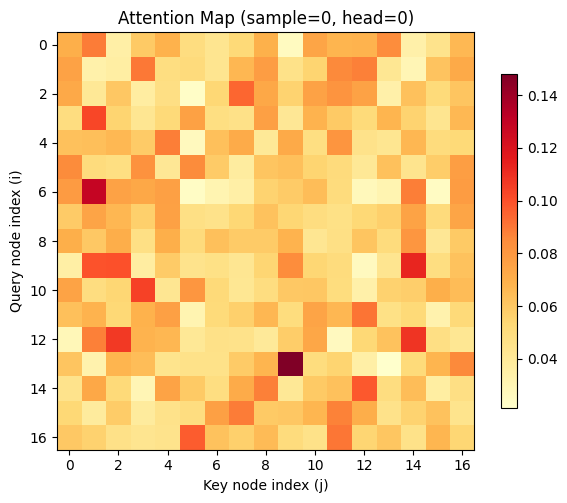

In [26]:
# ============================================================
# MHA shape trace + attention map visualization
# ============================================================

import math

# Demo setting
B_demo, N_demo, d_model_demo, num_heads_demo = 2, 17, 64, 4
H_demo = torch.randn(B_demo, N_demo, d_model_demo, device=device)

mha_demo = MultiHeadAttention(d_model=d_model_demo, num_heads=num_heads_demo, dropout=0.1).to(device)
mha_demo.eval()  # make attention deterministic for inspection

with torch.no_grad():
    B, N, _ = H_demo.size()

    # Manual trace for shape understanding
    Q = mha_demo.W_Q(H_demo).view(B, N, mha_demo.num_heads, mha_demo.d_k).transpose(1, 2)
    K = mha_demo.W_K(H_demo).view(B, N, mha_demo.num_heads, mha_demo.d_k).transpose(1, 2)
    V = mha_demo.W_V(H_demo).view(B, N, mha_demo.num_heads, mha_demo.d_k).transpose(1, 2)

    scores = torch.matmul(Q, K.transpose(-2, -1)) / mha_demo.scale
    attn_weights = F.softmax(scores, dim=-1)

    context = torch.matmul(attn_weights, V)
    context = context.transpose(1, 2).contiguous().view(B, N, mha_demo.d_model)
    out = mha_demo.W_O(context)

print("=== Shape Trace ===")
print(f"H_demo                : {tuple(H_demo.shape)}")
print(f"Q/K/V after split     : {tuple(Q.shape)}")
print(f"scores                : {tuple(scores.shape)}")
print(f"attn_weights          : {tuple(attn_weights.shape)}")
print(f"context (merged heads): {tuple(context.shape)}")
print(f"out                   : {tuple(out.shape)}")

# Check normalization on dim=-1 (sum over key nodes)
row_sums = attn_weights[0, 0].sum(dim=-1).detach().cpu().numpy()
print("\nRow sums of attention (sample0, head0, each query node):")
print(np.array2string(row_sums, precision=4, suppress_small=True))
print("(Should be ~1.0 for each query node)")

# Visualize one attention matrix [N, N]
attn_map = attn_weights[0, 0].detach().cpu().numpy()  # sample 0, head 0
plt.figure(figsize=(6, 5))
plt.imshow(attn_map, cmap="YlOrRd", aspect="equal")
plt.colorbar(shrink=0.8)
plt.title("Attention Map (sample=0, head=0)")
plt.xlabel("Key node index (j)")
plt.ylabel("Query node index (i)")
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# Gating Mechanism Implementation
# ============================================================

# During a tackle the 17 KPs output by YOLO contain a mix of "reliable" and "unreliable" detection
#Gating leans "let this feature pass through" or "suppress this feature" based on its confidence score as gate values between 0-1 using Sigmoid function

#   g = σ(W x + b)          ← gate vector (0~1)
#   z = x ⊙ g              ← element-wise multiplication

#   g = σ(W x + b)          ← gate vector (0~1)
#   z = x ⊙ g              ← element-wise multiplication
#
#   σ = sigmoid function: maps any value to 0~1
#   ⊙ = Hadamard product (element-wise multiplication)

class GatingMechanism(nn.Module):
    '''
    Confidence-aware gating for skeleton keypoints
    
    Suppresses afeatrure of low-confidence keypionts,
    so that features completed by GCN are weighted more heavilily
    '''
    
    def __init__(self, d_model):
        super().__init__()
        self.gate_linear = nn.Linear(d_model, d_model)  # Learnable linear layer for gating
    
    def forward(self, x):
        gate_values = torch.sigmoid(self.gate_linear(x))  # [B, N, d_model]
        gated = x * gate_values  # Element-wise multiplication
        return gated, gate_values

In [28]:
# ============================================================
# Complete GCT Layer Implementation
# ============================================================

# GCT = GCN + Multi-Head Attention + Gating + FFN

# Processing flow based on Dwivedi & Bresson (GCT paper), Eq. (4-8):

# 1. GCN  : Aggregate information from neighboring nodes (local)
# 2. Attn : Attention across all nodes (global)
# 3. Gate : Feature filtering based on reliability
# 4. FFN  : Non-linear transformation of features + residual connection
# 5. Nrom : Layer normalization

# GraphConvLayer already implemented as GraphConvLayer in the cell above

from torch import dropout
import math

class GCTLayer(nn.Module):
    '''
    Graph Convolutional Transformer Layer
    = GCN (local) + Attention (global) + gating + FFN
    '''
    
    def __init__(self, d_model, num_heads=4, ffn_dim=128, dropout=0.1):
        super().__init__()
        
        #1 GCN (local neighborhood aggregation)
        self.gcn = GraphConvLayer(d_model, d_model)
        
        #2 Multi-Head Attention (global context)
        self.attention = MultiHeadAttention(d_model, num_heads, dropout)
        
        #3 Gating Mechanism (confidence-aware feature filtering)
        self.gating = GatingMechanism(d_model)
        
        #4 Feed-Forward Network
        # FFN Linear (d-> ffn_dim) -> ReLu -> Linear (ffn_dim -> d)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout)
        )
        
        #5 Layer Normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, H, A_norm):
        """
        Processing flow: 
        H -> [GCN + Residual + Norm] -> [Attn + Gate + Residual + Norm]
          -> [FFN + Residual + Norm] -> H_new
          
        Parameters:
        H: [batch, 17, d_model]
        A_model: [17, 17] normalized adjacency matrix
        """
        # -- 1. GCN Layer ---
        gcn_out = self.gcn(H, A_norm)  # [B, 17, d_model]
        H = self.norm1(H + self.dropout(gcn_out))  # Residual + Norm
        
        # -- 2. Multi-Head Attention + Gating ---
        attn_out, attn_weights = self.attention(H)  # [B, 17, d_model], [B, num_heads, 17, 17]
        gated_out, gate_values = self.gating(attn_out)  # [B, 17, d_model], [B, 17, d_model]
        H = self.norm2(H + self.dropout(gated_out))  # Residual + Norm
        
        # -- 3. Feed-Forward Network ---
        ffn_out = self.ffn(H)  # [B, 17, d_model]
        H = self.norm3(H + self.dropout(ffn_out))  # Residual + Norm
        
        return H, attn_weights, gate_values
    
class SkeletonGCT(nn.Module):
    '''
    Complete Graph Convolutional Transformer
    
    input: Yolo keypoint features (x, y, conf, dx, dy) for 17 keypoints [batch, 17, 5]
    output: Updated keypoint features (e.g., for regression or classification) [batch, 17, 2]
    '''
    
    def __init__(self, in_features=5, d_model=64, num_heads=4, ffn_dim=128, num_layers=3, dropout=0.1):
        super().__init__()
        
        # Initial linear layer to project input features to d_model
        self.input_proj = nn.Linear(in_features, d_model)
        
        # Stacking multiple GCT layers
        self.layers = nn.ModuleList([
            GCTLayer(d_model, num_heads, ffn_dim, dropout) 
            for _ in range(num_layers)
        ])
        
        # Output: d_model -> 2 (for x, y regression)
        self.output_proj = nn.Linear(d_model, 2)
    
    def forward(self, H, A_norm):
        H = self.input_proj(H)  # [B, 17, d_model]
        all_attn = []
        for layer in self.layers:
            H, attn_w, gate_v = layer(H, A_norm)
            all_attn.append(attn_w)
        coords = self.output_proj(H)  # [B, 17, 2]
        return coords, all_attn
    

# Model initialization
model = SkeletonGCT(
        in_features=5,
        d_model=64,
        num_heads=4,
        ffn_dim=128,
        num_layers=3,
        dropout=0.1
    ).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Initialized SkeletonGCT model")
print(f"   Number of parameters: {total_params:,} ({total_params/1000:.1f}K)")
print(f"   Input: [batch, 17, 5] → Output: [batch, 17, 2]")
print(f"   Layers: {len(model.layers)} GCT layers (GCN + Attn + Gate + FFN)")


✅ Initialized SkeletonGCT model
   Number of parameters: 126,082 (126.1K)
   Input: [batch, 17, 5] → Output: [batch, 17, 2]
   Layers: 3 GCT layers (GCN + Attn + Gate + FFN)


## Phase4 Train model with actual video sample

In [29]:
# ============================================================
# Config
# ============================================================

import cv2, os, csv, time
from ultralytics import YOLO

TRAIN_VIDEO_PATH = r"C:\Users\User\OneDrive - National University of Singapore\Videos\Clipchamp\Video Project 10\Exports\Training sample 1.mp4"

EVAL_VIDEO_PATH = r"C:\Users\User\OneDrive - National University of Singapore\Documents\Video Project 4 ver.2.mp4"

YOLO26_MODEL_NAME = 'yolo26s-pose.pt'
OUTPUT_DIR = 'output_Yolo26_GCT'
os.makedirs(OUTPUT_DIR, exist_ok=True)

#Training parameters
CONF_THRESHOLD = 0.5 #All 17 KPs must exceed this to be GT
MASKS_PER_FRAME = 20  #Masked versions per GT frame
MASK_RATIO = 0.2     #Fraction of KPs to mask (~3-4 KPs per frame)
NOISE_STD = 0.02     #Standard deviation of noise added to masked KPs

#Verify model from Session2
try:
    _ = model; _ = A_norm_tensor; _ = A_norm
    print(f"GCT model ok: {sum(p.numel() for p in model.parameters()):,} params")
except NameError:
    print("❌ Run the previous cells to initialize the GCT model and adjacency matrix")


print(f"Training Video: {TRAIN_VIDEO_PATH}")
print(f"Evaluation Video: {EVAL_VIDEO_PATH}")


GCT model ok: 126,082 params
Training Video: C:\Users\User\OneDrive - National University of Singapore\Videos\Clipchamp\Video Project 10\Exports\Training sample 1.mp4
Evaluation Video: C:\Users\User\OneDrive - National University of Singapore\Documents\Video Project 4 ver.2.mp4


In [30]:
# ============================================================
# Extract Keypoints from video with YOLO 
# ============================================================

import cv2

yolo_det = YOLO(YOLO26_MODEL_NAME)


def extract_keypoints_from_video(video_path, conf_threshold=0.4):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"Video opened: {total_frames} frames, {W}x{H} @ {fps: .2f} FPS")
    
    all_frame_coords = []
    all_frame_confs = []
    gt_indices = []

    fi = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        res = yolo_det(frame, verbose=False, conf=0.1)[0]
        ok = (
            res.keypoints is not None
            and res.keypoints.data is not None
            and len(res.keypoints.data) > 0
        )

        if ok:
            pid = 0
            if res.boxes is not None and len(res.boxes.xyxy) > 1:
                bx = res.boxes.xyxy.detach().cpu().numpy()
                pid = int(np.argmax((bx[:, 2] - bx[:, 0]) * (bx[:, 3] - bx[:, 1])))  # Largest box = main player

            kp = res.keypoints.data[pid].detach().cpu().numpy()  # [17, 3]
            co = np.stack([kp[:, 0] / W, kp[:, 1] / H], axis=-1).astype(np.float32)  # Normalize to [0,1]
            cf = kp[:, 2].astype(np.float32)
            all_frame_coords.append(co)
            all_frame_confs.append(cf)

            if cf.min() >= conf_threshold:
                gt_indices.append(len(all_frame_coords) - 1)  # Index of GT frames
        else:
            all_frame_coords.append(np.zeros((17, 2), dtype=np.float32))
            all_frame_confs.append(np.zeros(17, dtype=np.float32))

        fi += 1
        if fi % 30 == 0:
            print(f"Processed {fi}/{total_frames} frames, GT frames so far: {len(gt_indices)}", end='\r')

    cap.release()

    all_frame_coords = np.array(all_frame_coords)  # [num_frames, 17, 2]
    all_frame_confs = np.array(all_frame_confs)    # [num_frames, 17]
    print(f"\nFinished processing video. Total GT frames: {len(gt_indices)}")

    return all_frame_coords, all_frame_confs, gt_indices, fps


train_coords, train_confs, train_gt_indices, train_fps = extract_keypoints_from_video(
    TRAIN_VIDEO_PATH,
    conf_threshold=CONF_THRESHOLD,)

if len(train_gt_indices) < 10:
        print("⚠️ Warning: Not enough GT frames found. Consider lowering CONF_THRESHOLD or checking video quality.")


Video opened: 807 frames, 2880x2160 @  30.00 FPS
Processed 780/807 frames, GT frames so far: 104
Finished processing video. Total GT frames: 104


In [31]:
# ============================================================
# Generate training samples from GT frames
# ============================================================
# From each GT frame, create MASKS_PER_FRAME training samples
# Each sample masks a different random subset of KPs
# Also includes velocity (dx, dy) from previous frame

def generate_training_data_from_vide(frame_coords, frame_confs, gt_idx_list, 
                                     masks_per_frame=20, mask_ratio=0.2, noise_std=0.02):
    inputs_list, targets_list, masks_list = [], [], []
    for gi in gt_idx_list:
        coords = frame_coords[gi]  # [17, 2]
        confs = frame_confs[gi]    # [17]
        dxy = coords - frame_coords[gi-1] if gi > 0 else np.zeros((17, 2), dtype=np.float32)  # Velocity (dx, dy)
        
        for _ in range(masks_per_frame):
            num_mask = max(1, int(mask_ratio * 17))  # Number of KPs to mask
            mask_ids = np.random.choice(17, num_mask, replace=False)  # Randomly select KPs to mask
            mask = np.ones(17, dtype=np.float32)
            mask[mask_ids] = 0  # Apply mask
            
            features = np.zeros((17, 5), dtype=np.float32)  # (x, y, conf, dx, dy)
            for i in range(17):
                if mask[i] == 1:
                    features[i] = [coords[i,0], coords[i,1], confs[i], dxy[i,0], dxy[i,1]]
                else:
                    features[i] = [coords[i,0] + np.random.randn()*noise_std*5,
                                   coords[i,1] + np.random.randn()*noise_std*5,
                                   0.05 + np.random.rand()*0.05,0.0,0.0]  # Low confidence for masked KPs
            inputs_list.append(features)  # [17, 5]
            targets_list.append(coords)   # [17, 2]
            masks_list.append(mask)     # [17]
    return (torch.FloatTensor(np.array(inputs_list)),  # [num_samples, 17, 5]
            torch.FloatTensor(np.array(targets_list)), # [num_samples, 17, 2]
            torch.FloatTensor(np.array(masks_list)))   # [num_samples, 17]
    
#80/20 train-test split
np.random.shuffle(train_gt_indices)
split = int(len(train_gt_indices)*0.8)
train_gt, val_gt, = train_gt_indices[:split], train_gt_indices[split:]

train_inputs, train_targets, train_masks = generate_training_data_from_vide(
    train_coords, train_confs, train_gt, MASKS_PER_FRAME, MASK_RATIO, NOISE_STD)
val_inputs, val_targets, val_masks = generate_training_data_from_vide(
    train_coords, train_confs, val_gt, MASKS_PER_FRAME, MASK_RATIO, NOISE_STD)

print(f"✅ Generated training data from video")
print(f"   Train samples: {train_inputs.shape[0]}, Val samples: {val_inputs.shape[0]}")
print(f"   Each sample shape: {train_inputs.shape[1:]} (17 keypoints, 5 features each)")
print(f"   GT frames x {MASKS_PER_FRAME} masked versions per frame")

✅ Generated training data from video
   Train samples: 1660, Val samples: 420
   Each sample shape: torch.Size([17, 5]) (17 keypoints, 5 features each)
   GT frames x 20 masked versions per frame


In [32]:
# ============================================================
# Training Loop (produces train_losses, val_losses)
# ============================================================

def masked_mse_loss(pred, target, mask):
    inv_mask = (1-mask).unsqueeze(-1)  # [B, 17, 1]
    diff = (pred - target) ** 2 
    return (diff * inv_mask).sum() / (inv_mask.sum() + 1e-8)  # Avoid division by zero

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
EPOCHS, BATCH_SIZE = 100, 64
train_losses, val_losses = [], []

print(f"Training GCT on {train_inputs.shape[0]} samples")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss, n_batches = 0,0
    indices = torch.randperm(len(train_inputs))
    for start in range(0, len(train_inputs),BATCH_SIZE):
        idx = indices[start:start+BATCH_SIZE]
        bx = train_inputs[idx].to(device)  # [B, 17, 5]
        by = train_targets[idx].to(device) # [B, 17, 2]
        bm = train_masks[idx].to(device)   # [B, 17]
        optimizer.zero_grad()
        pred, _ = model(bx, A_norm_tensor)  # [B, 17, 2]
        loss = masked_mse_loss(pred, by, bm)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    scheduler.step()
    train_losses.append(epoch_loss / n_batches)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_loss, n_batches = 0,0
        vp, _ = model(val_inputs.to(device), A_norm_tensor)
        vl = masked_mse_loss(vp, val_targets.to(device), val_masks.to(device))
        val_losses.append(vl.item())
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    
print(f'Train Finished. Final Train Loss: {train_losses[-1]:.4f}, Final Val Loss: {val_losses[-1]:.4f}')
    
    

Training GCT on 1660 samples
Epoch 10/100 - Train Loss: 0.0046, Val Loss: 0.0036
Epoch 20/100 - Train Loss: 0.0027, Val Loss: 0.0018
Epoch 30/100 - Train Loss: 0.0022, Val Loss: 0.0016
Epoch 40/100 - Train Loss: 0.0019, Val Loss: 0.0015
Epoch 50/100 - Train Loss: 0.0017, Val Loss: 0.0012
Epoch 60/100 - Train Loss: 0.0016, Val Loss: 0.0011
Epoch 70/100 - Train Loss: 0.0014, Val Loss: 0.0012
Epoch 80/100 - Train Loss: 0.0014, Val Loss: 0.0010
Epoch 90/100 - Train Loss: 0.0014, Val Loss: 0.0011
Epoch 100/100 - Train Loss: 0.0013, Val Loss: 0.0010
Train Finished. Final Train Loss: 0.0013, Final Val Loss: 0.0010


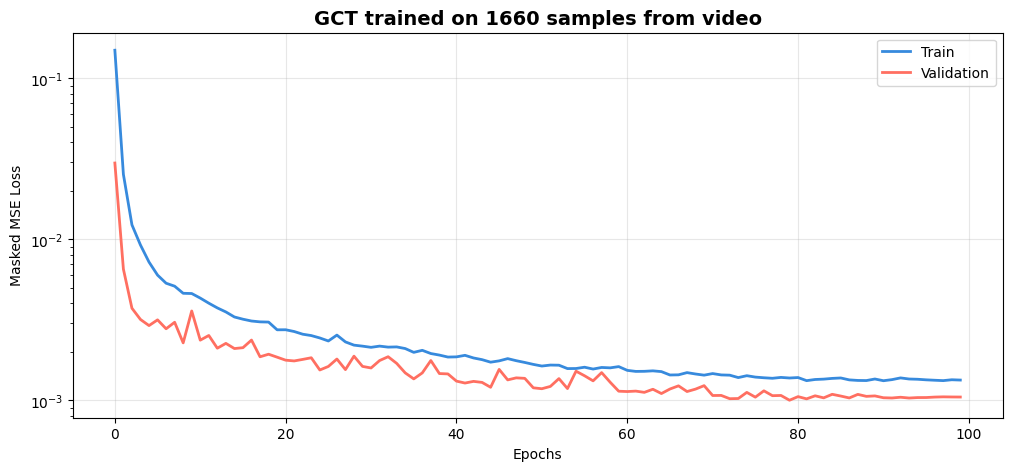

Model saved: skeleton_gct_model.pth


In [34]:
# ============================================================
# Training curve + model save
# ============================================================

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train_losses, label='Train', color = '#378ADD', linewidth=2)
ax.plot(val_losses, label='Validation', color = '#FF6F61', linewidth=2)
ax.set_xlabel('Epochs')
ax.set_ylabel('Masked MSE Loss')
ax.set_title(f'GCT trained on {len(train_inputs)} samples from video', fontsize=14, fontweight='bold')
ax.legend()
ax.set_yscale('log')
ax.grid(alpha=0.3)
plt.show()

torch.save({'model_state_dict': model.state_dict(), 'A_norm': A_norm,
    'config': {'in_features':5,'d_model':64,'num_heads':4,'num_layers':3,'ffn_dim':128},
    'train_losses': train_losses, 'val_losses': val_losses,
    'gt_frames': len(train_gt_indices)}, 'skeleton_gct_model.pth')
print('Model saved: skeleton_gct_model.pth')

## Phase5 Evaluation: Apply trained GCT on all frames

In [36]:
# ============================================================
# Extract Keypoints from EVAL viddeo (Rugby Tackle; occulusion)
# ============================================================

EVAL_CONF_THRESHOLD = 0.3 #Lower threshold to capture more frames with partial occlusion

eval_coords, eval_confs, eval_gt_indices, eval_fps = extract_keypoints_from_video(
    EVAL_VIDEO_PATH, EVAL_CONF_THRESHOLD)

#Count occulusion frames
oc_frames = np.sum(eval_confs < EVAL_CONF_THRESHOLD)
print(f"Evaluation video has {len(eval_coords)} frames, {eval_gt_indices} GT frames, "
      f"{oc_frames} occluded frames (conf < {EVAL_CONF_THRESHOLD})")

Video opened: 80 frames, 3840x2160 @  30.00 FPS
Processed 60/80 frames, GT frames so far: 0
Finished processing video. Total GT frames: 0
Evaluation video has 80 frames, [] GT frames, 241 occluded frames (conf < 0.3)


In [37]:
# ============================================================
# Apply trained GCT to EVAL video
# ============================================================

model.eval()
gct_eval = np.zeros_like(eval_coords)  # [num_frames, 17, 2]

for fi in range(len(eval_coords)):
    c = eval_coords[fi]  # [17, 2]
    cf = eval_confs[fi]    # [17]
    dxy = c - eval_coords[fi-1] if fi > 0 else np.zeros((17, 2), dtype=np.float32)  # Velocity (dx, dy)
    feat = np.stack([c[:,0], c[:,1], cf, dxy[:,0], dxy[:,1]], axis=-1).astype(np.float32)  # [17, 5]
    with torch.no_grad():
        ref,_ = model(torch.FloatTensor(feat).unsqueeze(0).to(device), A_norm_tensor)  # [1, 17, 2]
    r = ref[0].cpu().numpy()  # [17, 2]
    for i in range(17):
        alpha = min(cf[i],1.0)
        gct_eval[fi,i] = alpha * c[i] + (1-alpha) * r[i]  # Blend original and GCT output based on confidence
print("✅ Applied trained GCT to EVAL video")

✅ Applied trained GCT to EVAL video


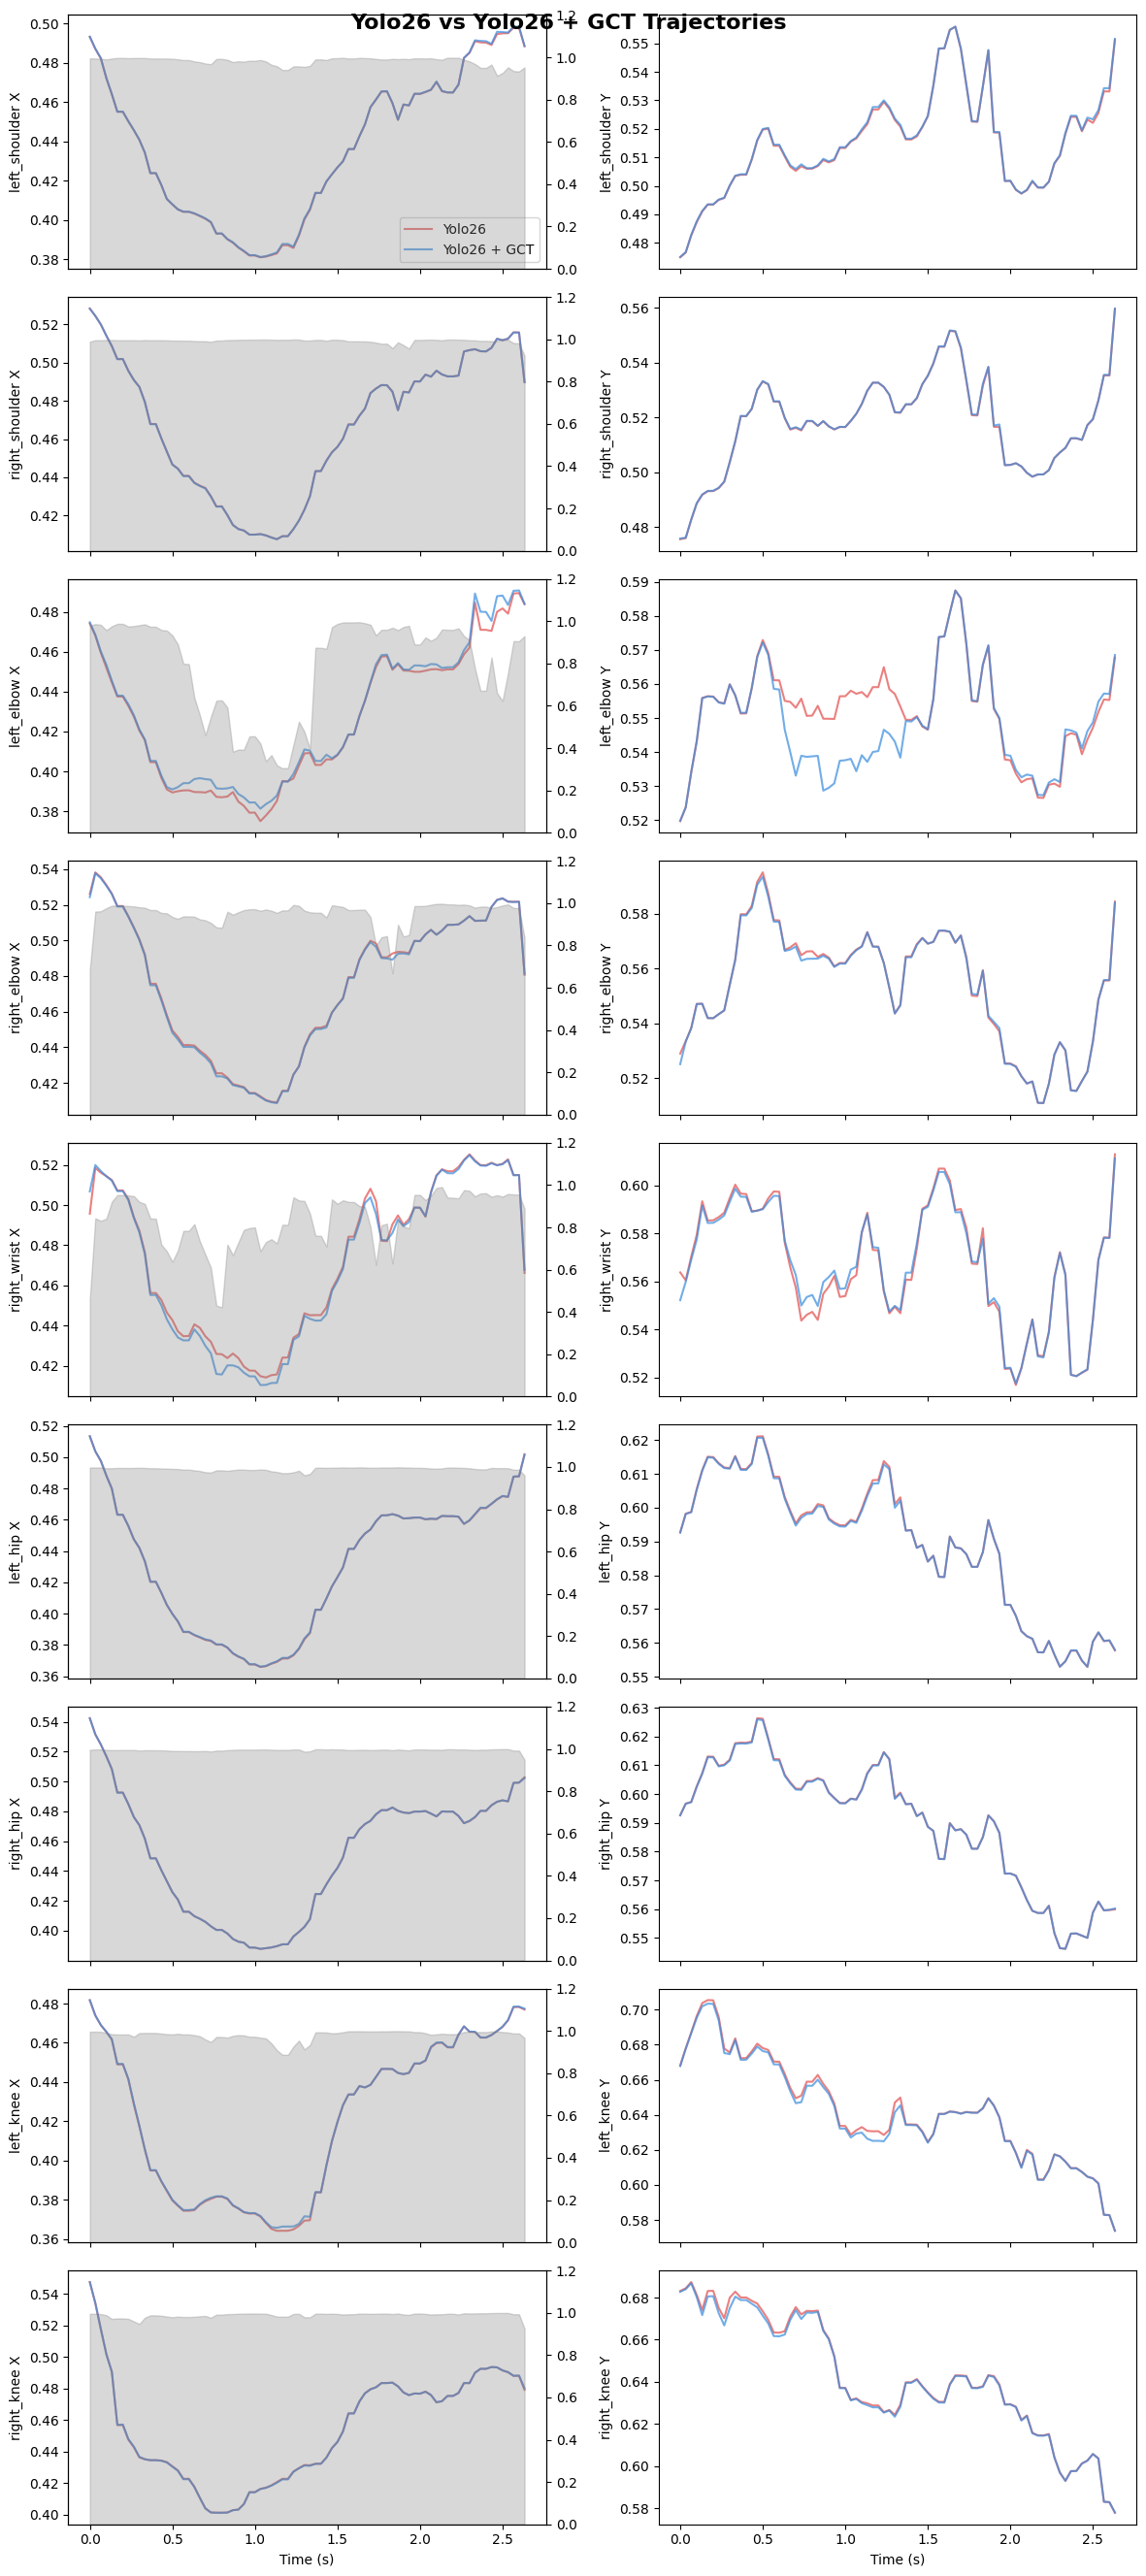

In [38]:
# ============================================================
# Trajectory comparison
# ============================================================
KP_NAMES = ['nose','left_eye','right_eye','left_ear','right_ear',
  'left_shoulder','right_shoulder','left_elbow','right_elbow',
  'left_wrist','right_wrist','left_hip','right_hip',
  'left_knee','right_knee','left_ankle','right_ankle']

eval_timestamps = np.arange(len(eval_coords)) / eval_fps
focus_kps = [5,6,7,8,10,11,12,13,14]  # right_shoulder, right_elbow, right_wrist, right_hip , right_knee

fig, axes = plt.subplots(len(focus_kps), 2, figsize=(12, 3*len(focus_kps)), sharex=True)
fig.suptitle('Yolo26 vs Yolo26 + GCT Trajectories', fontsize=16, fontweight='bold')
for row, ki in enumerate(focus_kps):
    dim_labels = ['X', 'Y']
    for col, dim in [(0,0), (1,1)]:
        ax = axes[row, col]
        ax.plot(eval_timestamps, eval_coords[:,ki,dim], label='Yolo26', color='#E24B4A', alpha=0.7)
        ax.plot(eval_timestamps, gct_eval[:,ki,dim], label='Yolo26 + GCT', color='#378ADD', alpha=0.7)
        ax.set_ylabel(f"{KP_NAMES[ki]} {dim_labels[dim]}")
        if row==0 and col==0: ax.legend()
    ax2 = axes[row,0].twinx()
    ax2.fill_between(eval_timestamps, eval_confs[:,ki], color='gray', alpha=0.3)
    ax2.set_ylim(0,1.2)
axes[-1,0].set_xlabel('Time (s)'); axes[-1,1].set_xlabel('Time (s)')
plt.tight_layout()

In [ ]:
# ============================================================
# Jitter analysis
# ============================================================

def compute_jitter(c):
    '''
    # what is jitter: frame-to-frame instability in keypoint positions, measured as the average distance between consecutive frames
    # GCT not improves the confidence score, so we look at jitter reduction in all frames and occluded frames (conf < threshold) separately
    #Occ: frames where the confidence score is low (e.g., conf < 0.5), indicating potential occlusion or unreliable detections. 
    # We want to see if GCT can reduce jitter in these challenging frames, which would suggest that it helps stabilize keypoint predictions even when the input is noisy or partially missing.
    '''
    
    d = np.diff(c, axis=0)  # [num_frames-1, 2]
    return np.sqrt((d**2).sum(axis=-1))  # [num_frames-1]
yj, gj = compute_jitter(eval_coords), compute_jitter(gct_eval)  

print(f'{"KP":>18s}  {"YOLO":>10s}  {"GCT":>10s}  {"Reduce":>8s}  {"Occ YOLO":>10s}  {"Occ GCT":>10s}  {"Occ Red":>8s}')
print('-' * 80)
for k in range(17):
    a, b = yj[:,k].mean(), gj[:,k].mean()
    r = (1 - b/a) * 100 if a > 0 else 0
    om = eval_confs[1:, k] < 0.5
    if om.sum() > 0:
        oa, ob = yj[om,k].mean(), gj[om,k].mean()
        ro = (1 - ob/oa) * 100 if oa > 0 else 0
    else: oa = ob = ro = 0
    print(f'{KP_NAMES[k]:>18s}  {a:10.5f}  {b:10.5f}  {r:+7.1f}%  {oa:10.5f}  {ob:10.5f}  {ro:+7.1f}%')

                KP        YOLO         GCT    Reduce    Occ YOLO     Occ GCT   Occ Red
--------------------------------------------------------------------------------
              nose     0.00697     0.00746     -7.1%     0.00643     0.00676     -5.2%
          left_eye     0.00711     0.00833    -17.2%     0.00711     0.00833    -17.2%
         right_eye     0.00696     0.00824    -18.4%     0.00689     0.00796    -15.5%
          left_ear     0.00679     0.00736     -8.4%     0.00646     0.00662     -2.4%
         right_ear     0.00667     0.00712     -6.8%     0.01150     0.01099     +4.5%
     left_shoulder     0.00590     0.00590     -0.1%     0.00000     0.00000     +0.0%
    right_shoulder     0.00570     0.00570     -0.1%     0.00000     0.00000     +0.0%
        left_elbow     0.00634     0.00666     -5.0%     0.00415     0.00484    -16.8%
       right_elbow     0.00720     0.00716     +0.5%     0.00000     0.00000     +0.0%
        left_wrist     0.00893     0.00845     +5

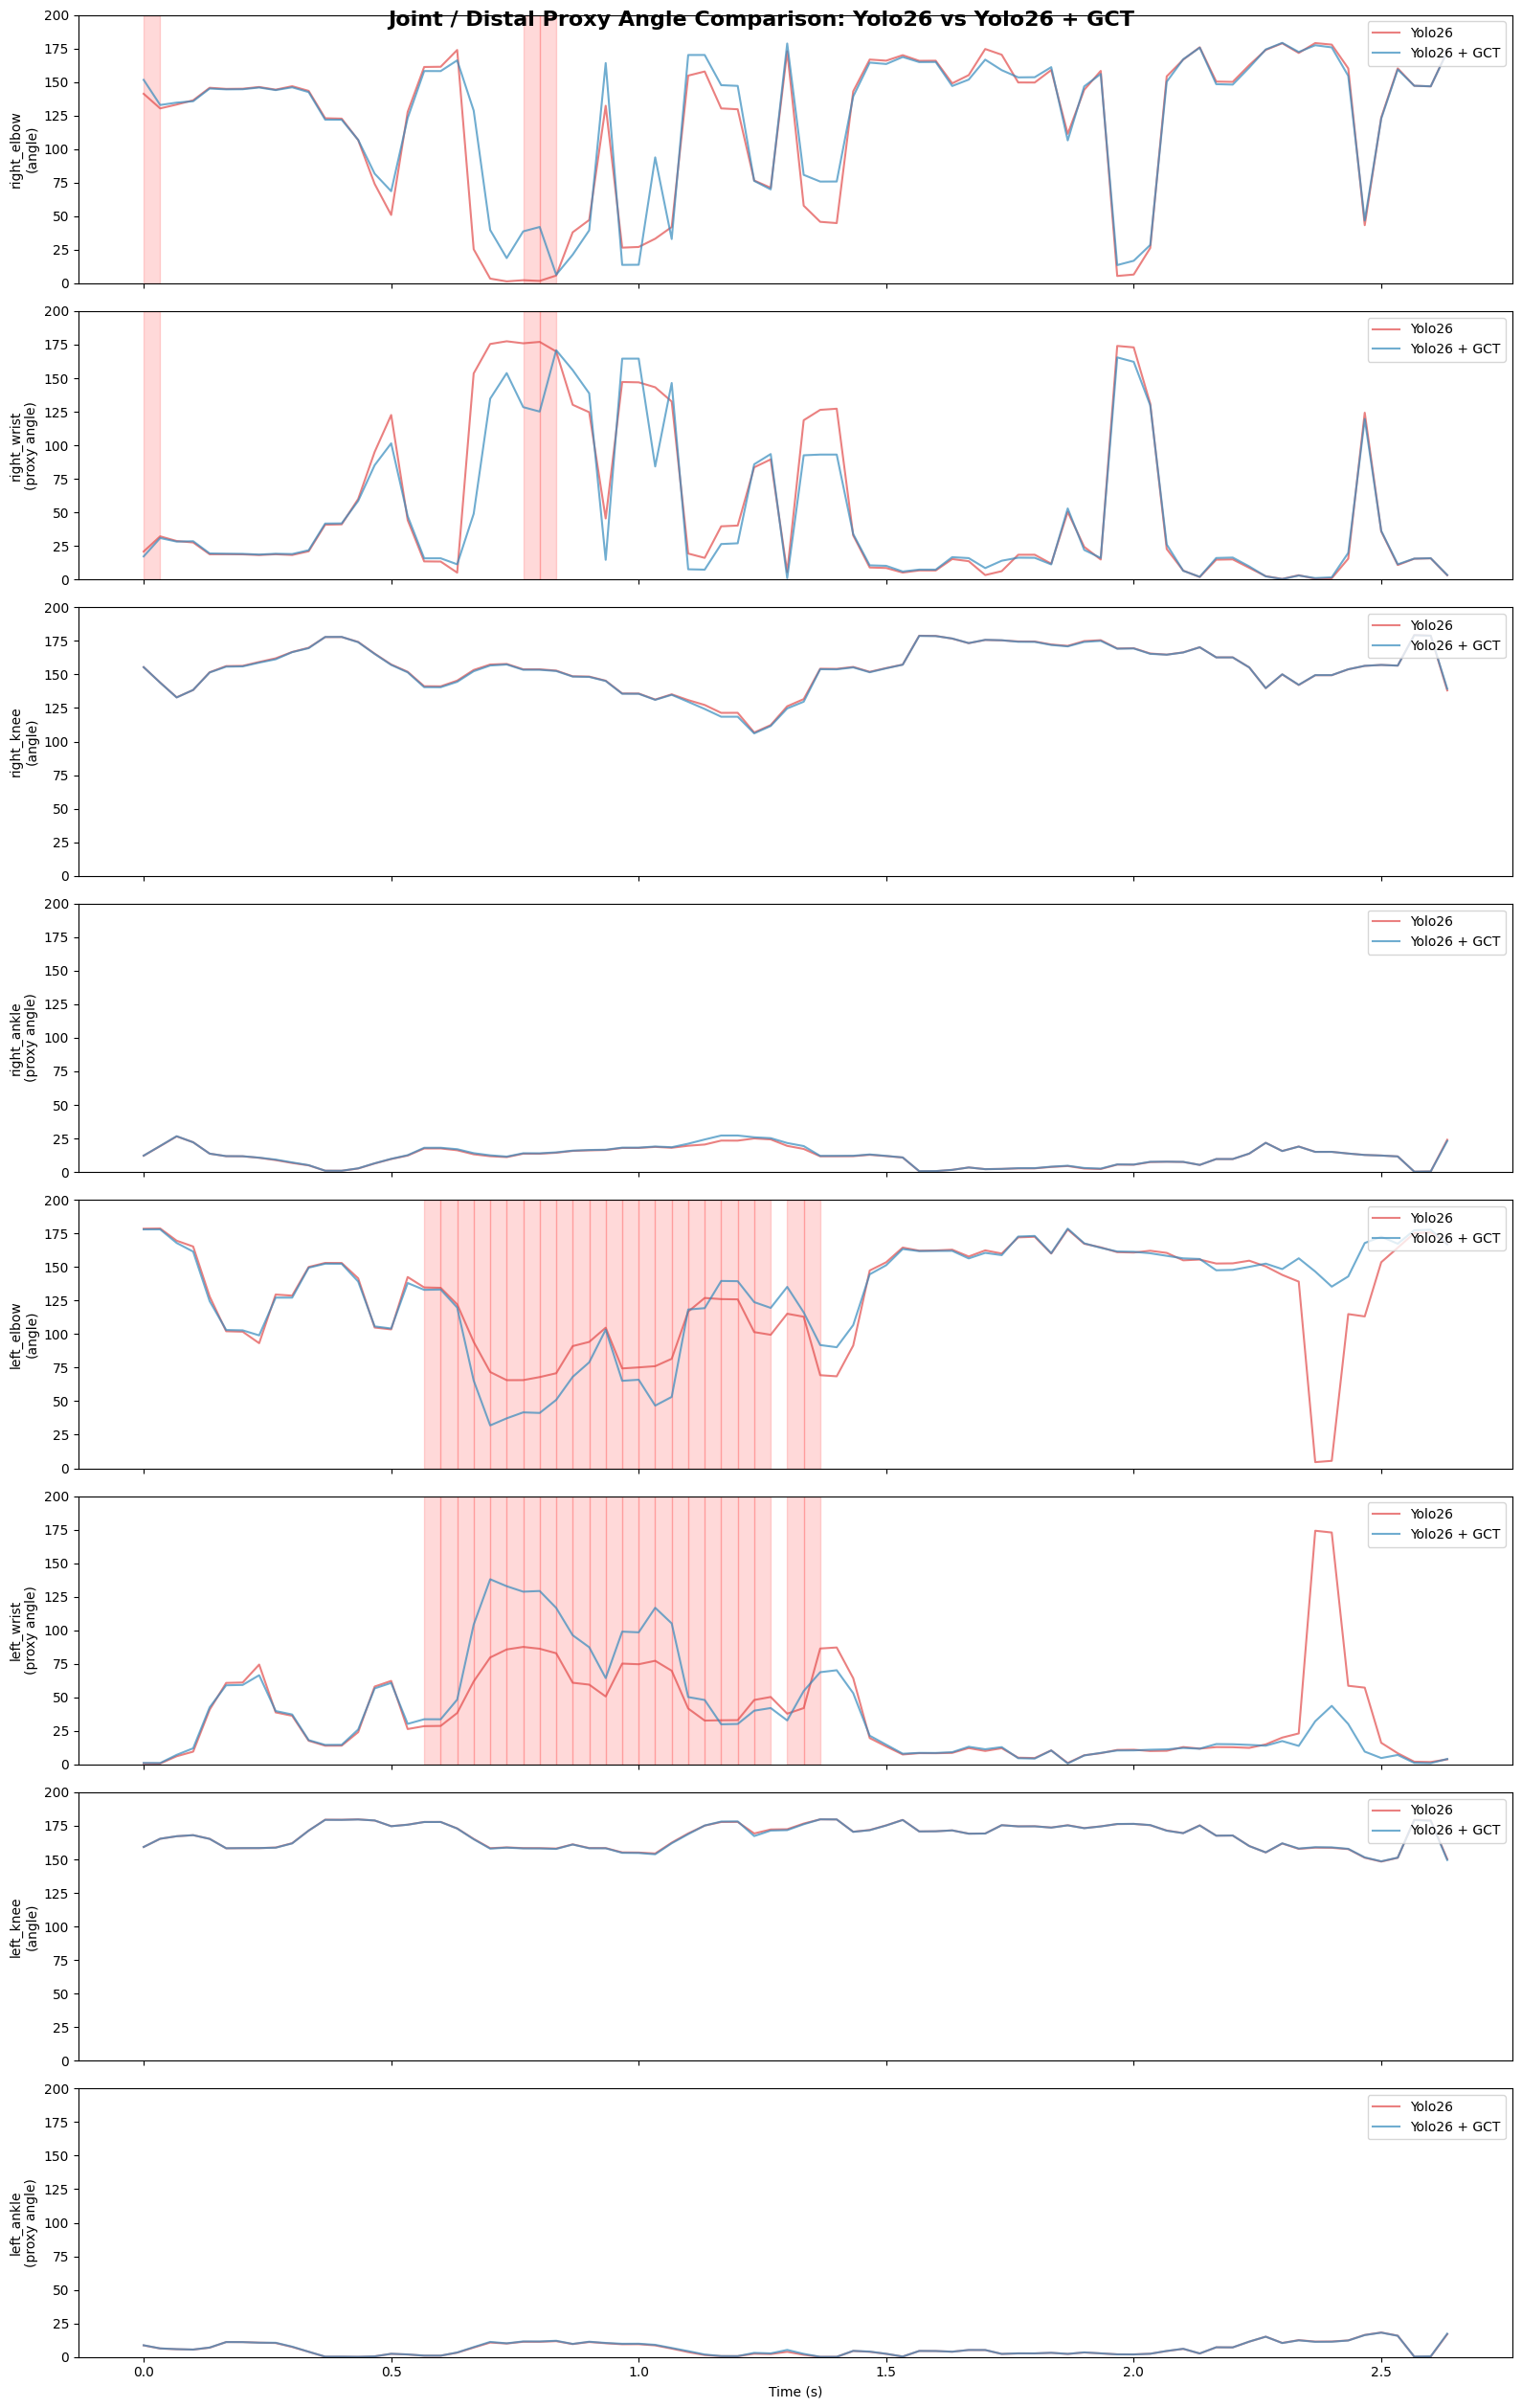

CSV saved: output_Yolo26_GCT\gct_refined_results.csv


In [ ]:
# ============================================================
# Angle comparison Yolo26 vs GCT
# ============================================================

def calc_ang(a,b,c):
    ba = a - b
    bc = c - b
    ct = np.dot(ba,bc) / (np.linalg.norm(ba)*np.linalg.norm(bc) + 1e-8)
    return float(np.degrees(np.arccos(np.clip(ct, -1, 1))))

JAD = {'right_elbow':(6,8,10), 'left_elbow':(5,7,9),
       'right_knee':(12,14,16), 'left_knee':(11,13,15),
       'right_shoulder':(8,6,12), 'left_shoulder':(7,5,11),
       'right_hip':(6,12,14), 'left_hip':(5,11,13)}

# Compute all angles
yolo_angles = {n:[] for n in JAD}
gct_angles = {n:[] for n in JAD}
for fi in range(len(eval_timestamps)):
    for n, (a,b,c) in JAD.items():
        yolo_angles[n].append(calc_ang(eval_coords[fi,a], eval_coords[fi,b], eval_coords[fi,c]))
        gct_angles[n].append(calc_ang(gct_eval[fi,a], gct_eval[fi,b], gct_eval[fi,c]))
        
#Plot
cj = ['right_elbow', 'right_knee', 'left_elbow', 'left_knee']
fig, axes = plt.subplots(len(cj),1, figsize=(16,3.5*len(cj)), sharex=True)
fig.suptitle('Joint Angle Comparison: Yolo26 vs Yolo26 + GCT', fontsize=16, fontweight='bold')
for idx, jn in enumerate(cj):
    a_id, b_id, c_id = JAD[jn]
    ax = axes[idx]
    ax.plot(eval_timestamps, yolo_angles[jn], label='Yolo26', color='#E24B4A', alpha=0.7)
    ax.plot(eval_timestamps, gct_angles[jn], label='Yolo26 + GCT', color='#348ABD', alpha=0.7)
    mc = eval_confs[:, [a_id, b_id, c_id]].min(axis=1)
    for f in range(len(eval_timestamps)-1):
        if mc[f] < 0.5:
            ax.axvspan(eval_timestamps[f], eval_timestamps[f]+1, color='Red', alpha=.15)
    ax.set_ylabel(f'{jn} Angle (degrees)')
    ax.legend(loc='upper right')
    ax.set_ylim(0,200)
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

# CSV
csv_path = os.path.join(OUTPUT_DIR, 'gct_refined_results.csv')
headers = ['frame','timestamp_s']
headers += [f'angle_{n}_yolo' for n in JAD]
headers += [f'angle_{n}_gct' for n in JAD]
headers += [f'conf_{KP_NAMES[i]}' for i in range(17)]
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f); w.writerow(headers)
    for fi in range(len(eval_timestamps)):
        row = [fi, f'{eval_timestamps[fi]:.4f}']
        for n in JAD: row.append(f'{yolo_angles[n][fi]:.2f}')
        for n in JAD: row.append(f'{gct_angles[n][fi]:.2f}')
        for i in range(17): row.append(f'{eval_confs[fi,i]:.3f}')
        w.writerow(row)
print(f'CSV saved: {csv_path}')

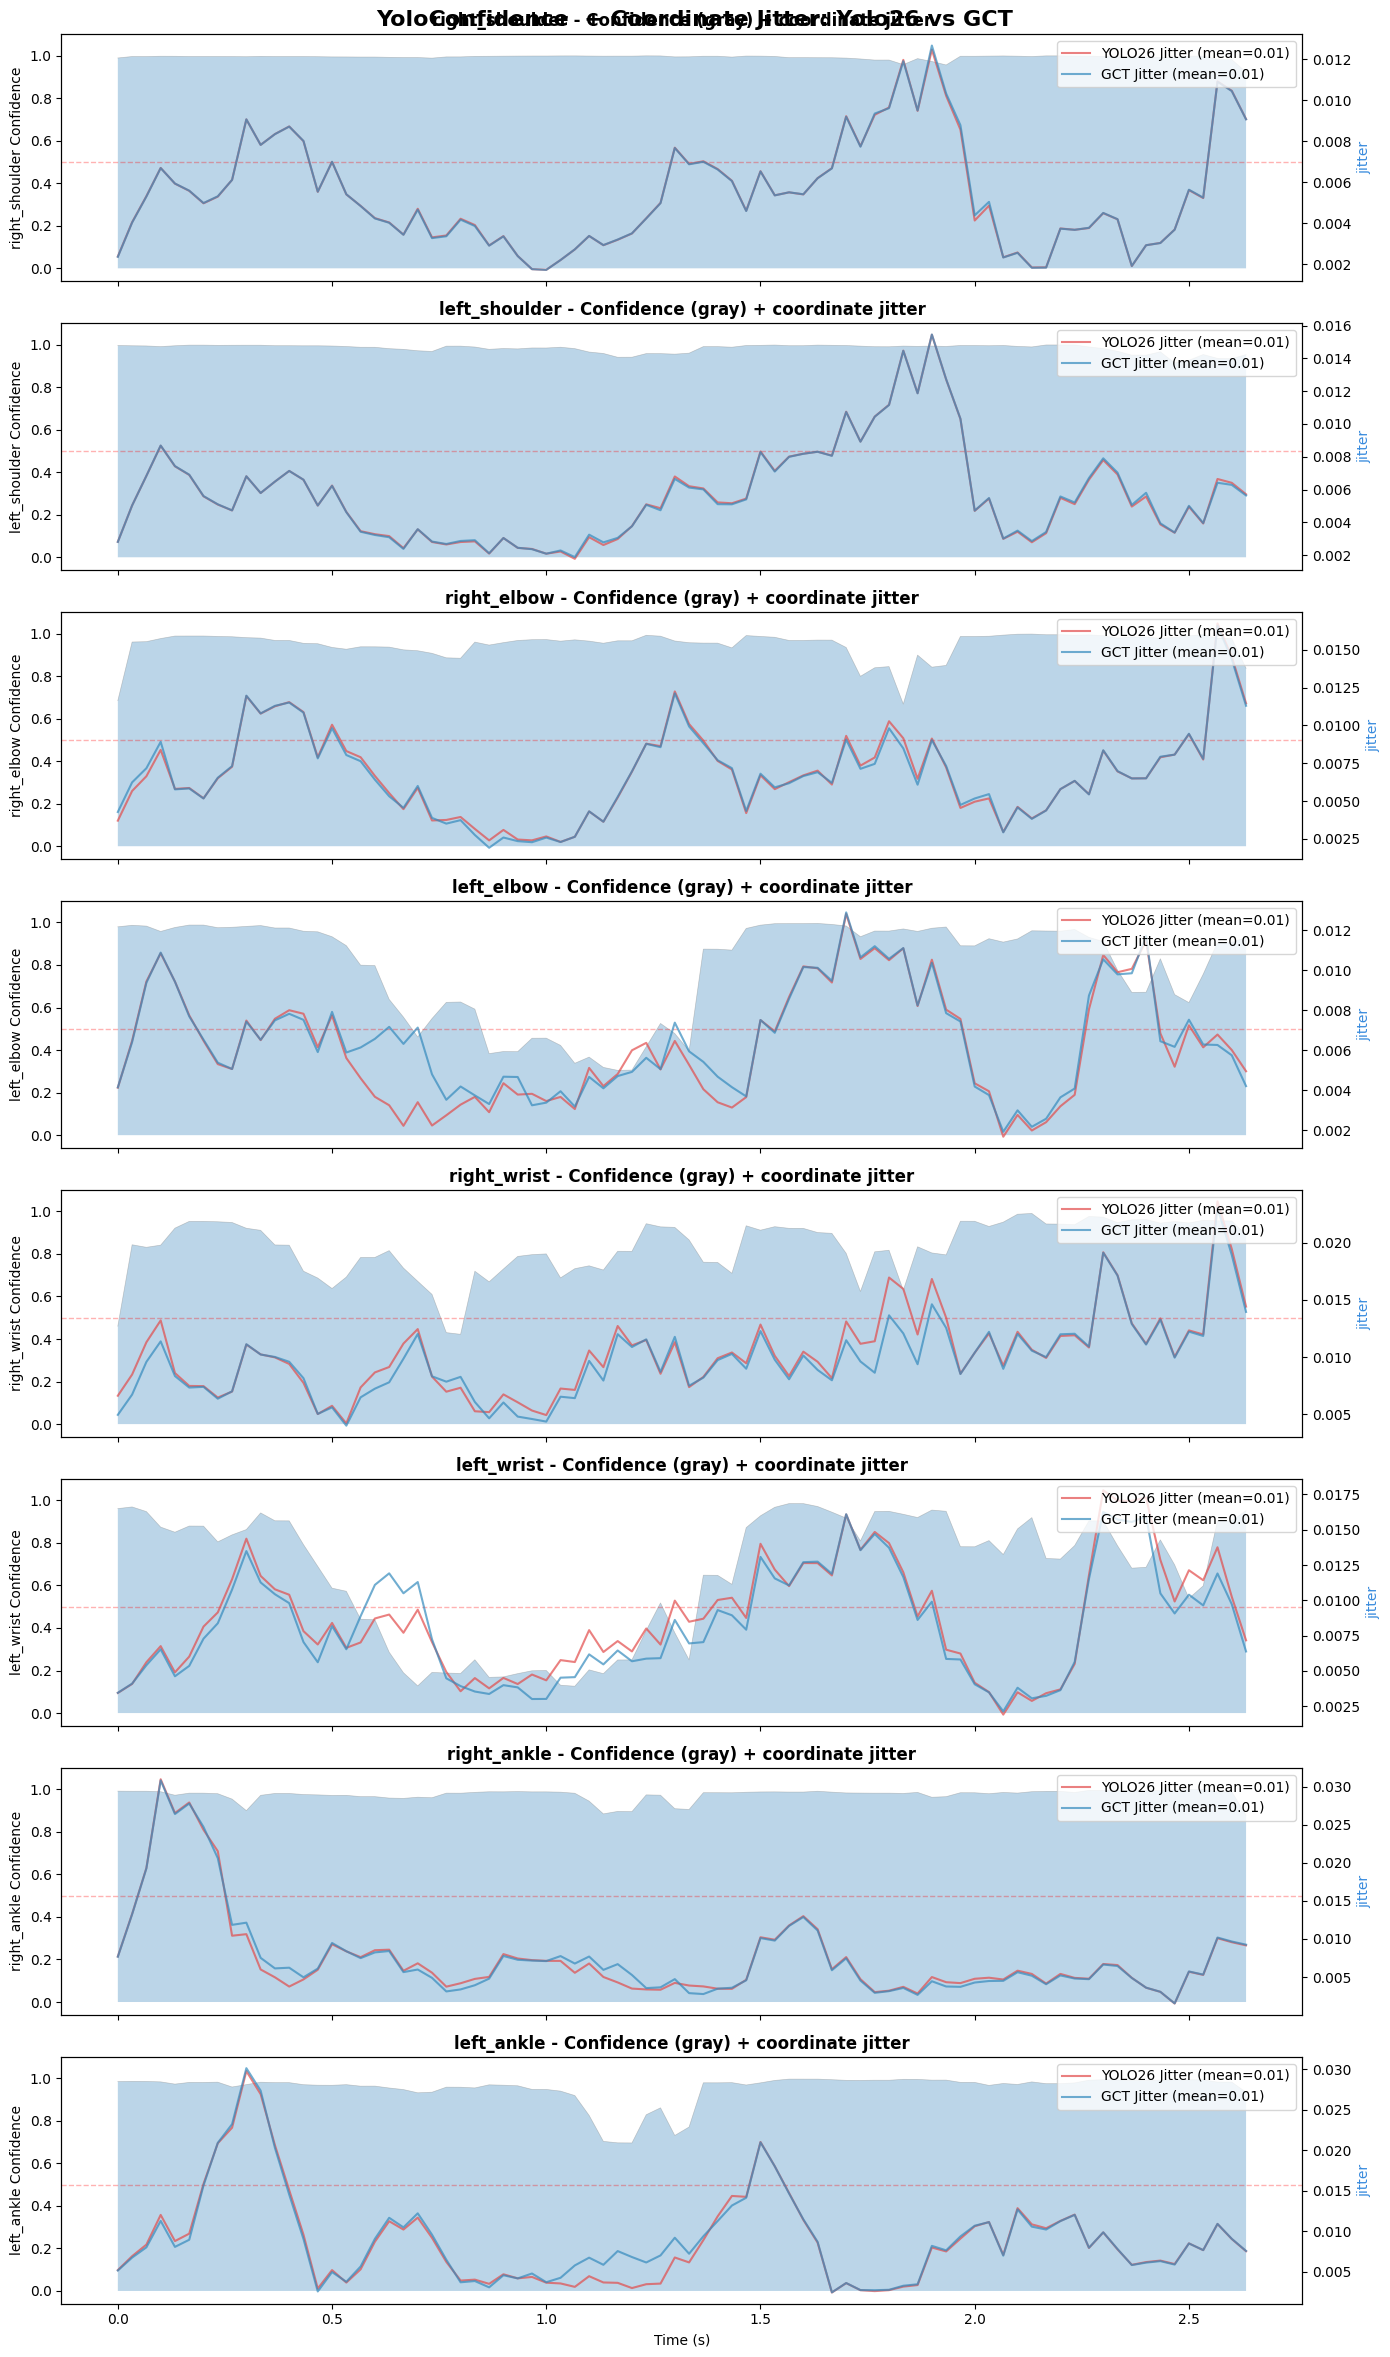

In [43]:
# ============================================================
# Confidence timeline + angle stability comparison 
# ============================================================
# 

#Compute per-frame jitter for each KP
def frame_jitter(coords):
    j = np.zeros_like(coords[:,:,0]) # [num_frames, 17]
    for i in range(1, len(coords)):
        j[i] = np.sqrt(((coords[i] - coords[i-1])**2).sum(axis=-1))  # [17]
    return j

yolo_fj = frame_jitter(eval_coords)  # [num_frames, 17]
gct_fj = frame_jitter(gct_eval)      # [num_frames,

# --- Timeline plot: Confidence + Jitter for focus joint --- 
focus = [
    ('right_shoulder', 6), ('left_shoulder', 5), ('right_elbow', 8), ('left_elbow', 7), ('right_wrist', 10), ('left_wrist', 9),
    ('right_ankle', 16), ('left_ankle', 15)
]

fig, axes = plt.subplots(len(focus), 1, figsize=(14, 3*len(focus)), sharex=True)
fig.suptitle('YoloConfidence  + Coordinate Jitter: Yolo26 vs GCT', fontsize=16, fontweight='bold')

for idx, (name, ki) in enumerate(focus):
    ax = axes[idx]
    
    #Confidence (Same for both since GCT doesn't change conf)
    ax.fill_between(eval_timestamps, eval_confs[:,ki], alpha=0.3, label='Confidence')
    ax.plot(eval_timestamps, eval_confs[:,ki], color='gray', alpha=0.4, lw=0.5)
    
    #Jitter (actual comparison metric)
    win = 5
    yj_smooth = np.convolve(yolo_fj[:,ki], np.ones(win)/win, mode='same')
    gj_smooth = np.convolve(gct_fj[:,ki], np.ones(win)/win, mode='same')
    
    ax2 = ax.twinx()
    ax2.plot(eval_timestamps, yj_smooth, label=f'YOLO26 Jitter (mean={yolo_fj[:,ki].mean():.2f})', color='#E24B4A', alpha=0.7, lw=1.5)
    ax2.plot(eval_timestamps, gj_smooth, label=f'GCT Jitter (mean={gct_fj[:,ki].mean():.2f})', color='#348ABD', alpha=0.7, lw=1.5)
    ax2.set_ylabel('jitter', color= '#378ADD')
    ax2.legend(loc='upper right')
    
    ax.set_ylabel(f'{name} Confidence', fontsize=10)
    ax.set_ylim(-0.06,1.1)
    ax.set_title(f'{name} - Confidence (gray) + coordinate jitter', fontsize=12, fontweight='bold')
    
    ax.axhline(0.5, color='red', alpha=0.3, ls='--', lw=1)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout() 
plt.show()

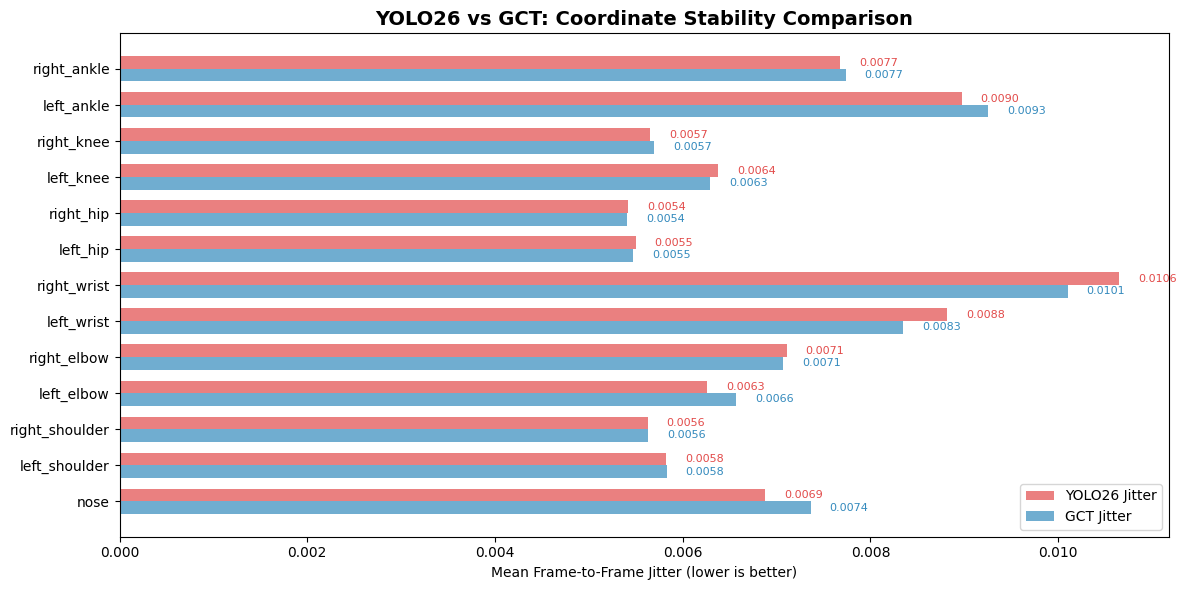

In [49]:
# ============================================================
# Mean jitter per joint - YOLO vs GCT
# ============================================================
all_joints = ['nose', 'left_shoulder','right_shoulder','left_elbow','right_elbow',
              'left_wrist','right_wrist','left_hip','right_hip',
              'left_knee','right_knee','left_ankle','right_ankle']
joint_ids = [0,5,6,7,8,9,10,11,12,13,14,15,16]

yolo_means = [yolo_fj[:, ji].mean() for ji in joint_ids]
gct_means = [gct_fj[:, ji].mean() for ji in joint_ids]

fig, ax = plt.subplots(figsize=(12,6))
y_pos = np.arange(len(all_joints))
bh = 0.35

bar1 = ax.barh(y_pos + bh/2, yolo_means, height=bh, label='YOLO26 Jitter', color='#E24B4A', alpha=0.7)
bar2 = ax.barh(y_pos - bh/2, gct_means, height=bh, label='GCT Jitter', color='#348ABD', alpha=0.7)

for bar, val in zip(bar1, yolo_means):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8, color='#E24B4A')
for bar, val in zip(bar2, gct_means):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8, color='#348ABD')
    
ax.set_yticks(y_pos)
ax.set_yticklabels(all_joints)
ax.set_xlabel('Mean Frame-to-Frame Jitter (lower is better)')
ax.set_title('YOLO26 vs GCT: Coordinate Stability Comparison', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

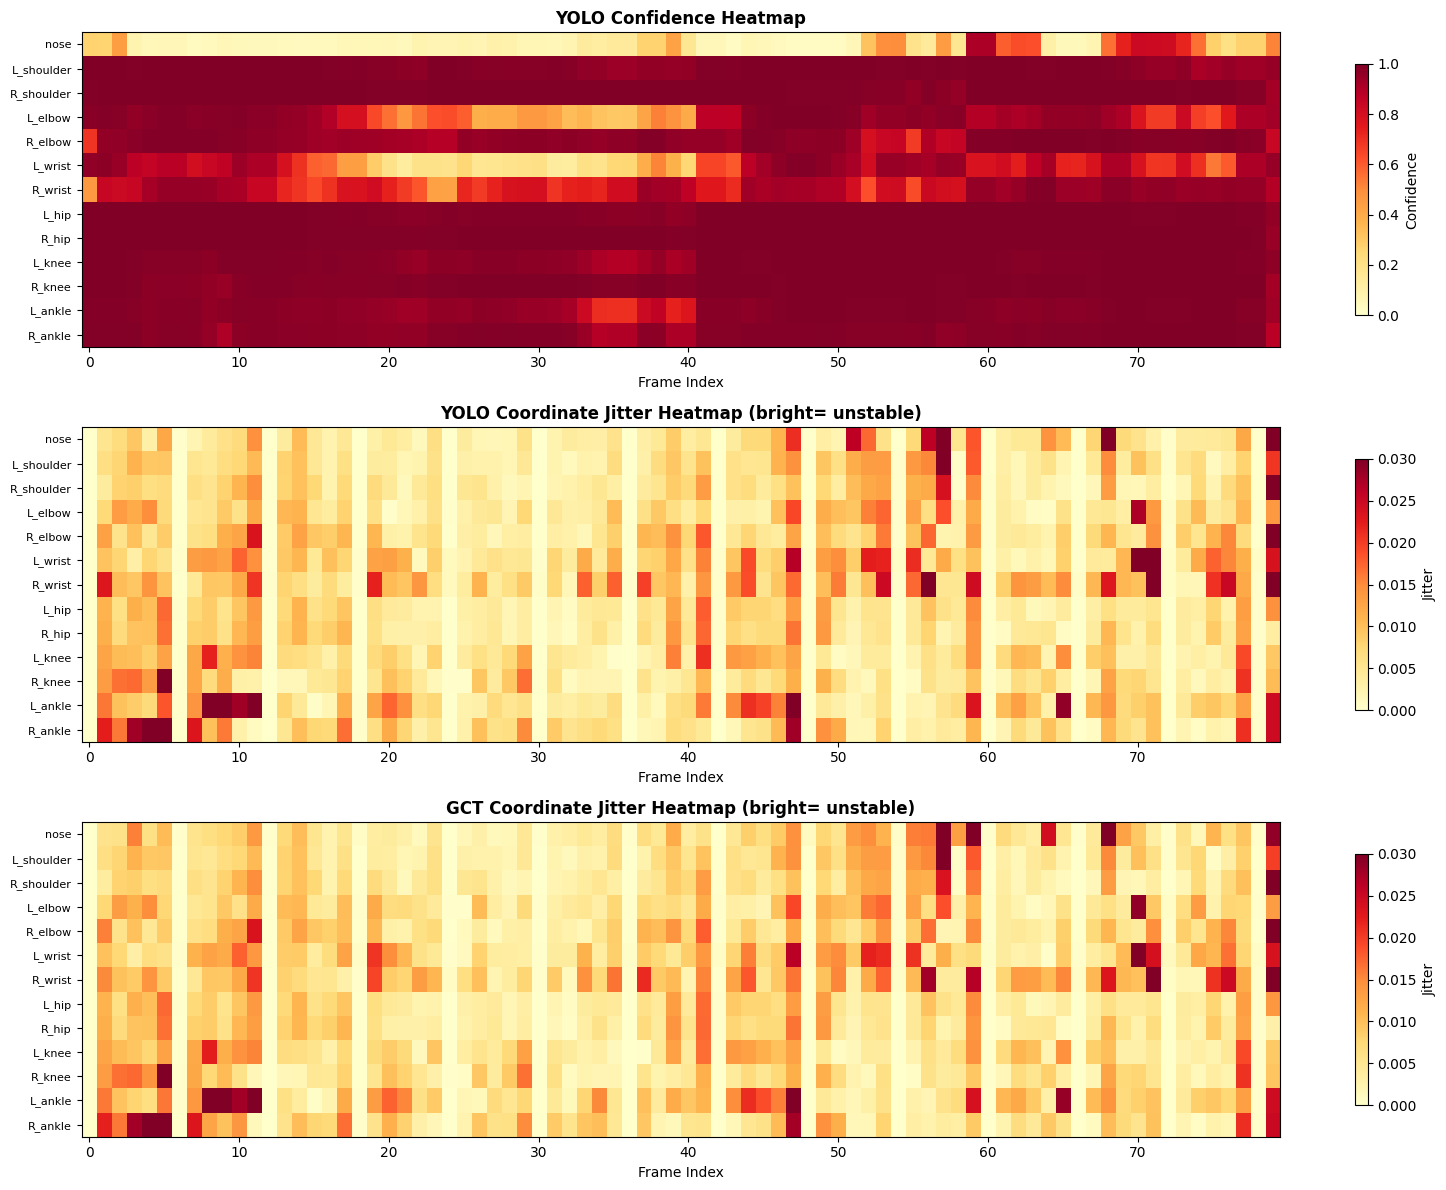

In [52]:

# ============================================================
# Heatmaps: Yolo confidence + Yolo Jitter + GCT Jitter
# ============================================================

KP_SHORT = ['nose','L_shoulder','R_shoulder','L_elbow','R_elbow',
            'L_wrist','R_wrist','L_hip','R_hip',
            'L_knee','R_knee','L_ankle','R_ankle']
ki_order = [0,5,6,7,8,9,10,11,12,13,14,15,16]

fig, axes = plt.subplots(3,1, figsize=(16,12))

# --- Confidence heatmap ---
ax = axes[0]
conf_data = eval_confs[:, ki_order].T  # [13, num_frames]
im = ax.imshow(conf_data, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_yticks(np.arange(len(KP_SHORT)))
ax.set_yticklabels(KP_SHORT, fontsize=8)
ax.set_title('YOLO Confidence Heatmap', fontsize=12, fontweight='bold')
ax.set_xlabel('Frame Index')
plt.colorbar(im, ax=ax, shrink=0.8, label='Confidence')

# --- YOLO Jitter heatmap ---
ax = axes[1]
yolo_jitter_data = yolo_fj[:, ki_order].T  # [13, num_frames]
im = ax.imshow(yolo_jitter_data, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.03)
ax.set_yticks(range(len(KP_SHORT)))
ax.set_yticklabels(KP_SHORT, fontsize=8)
ax.set_title('YOLO Coordinate Jitter Heatmap (bright= unstable)', fontsize=12, fontweight='bold')
ax.set_xlabel('Frame Index')
plt.colorbar(im, ax=ax, shrink=0.8, label='Jitter')

# --- GCT Jitter heatmap ---
ax = axes[2]
gct_jitter_data = gct_fj[:, ki_order].T  # [13, num_frames]
im = ax.imshow(gct_jitter_data, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.03)
ax.set_yticks(range(len(KP_SHORT)))
ax.set_yticklabels(KP_SHORT, fontsize=8)
ax.set_title('GCT Coordinate Jitter Heatmap (bright= unstable)', fontsize=12, fontweight='bold')
ax.set_xlabel('Frame Index')
plt.colorbar(im, ax=ax, shrink=0.8, label='Jitter')

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Annotated Video: YOLO26+GCT skeleton overlay
# ============================================================
# Draws GCT-refined keypoints and skeleton on each frame.
# Color-coded: green = high conf, red = low conf (GCT active)
# Borrow code from AI 

SKELETON_CONNECTIONS = [
    (0, 5), (0, 6),        # nose to shoulders
    (5, 6),                 # shoulder to shoulder
    (5, 7), (7, 9),         # left arm
    (6, 8), (8, 10),        # right arm
    (5, 11), (6, 12),       # shoulders to hips
    (11, 12),               # hip to hip
    (11, 13), (13, 15),     # left leg
    (12, 14), (14, 16),     # right leg
]

KP_NAMES = ['nose','left_eye','right_eye','left_ear','right_ear',
  'left_shoulder','right_shoulder','left_elbow','right_elbow',
  'left_wrist','right_wrist','left_hip','right_hip',
  'left_knee','right_knee','left_ankle','right_ankle']

cap = cv2.VideoCapture(EVAL_VIDEO_PATH)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out_path = os.path.join(OUTPUT_DIR, 'annotated_gct.mp4')
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(out_path, fourcc, eval_fps, (W, H))

fi = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret or fi >= len(gct_eval): break
    
    gct_px = gct_eval[fi].copy()  # [17, 2] normalized
    gct_px[:, 0] *= W
    gct_px[:, 1] *= H
    confs = eval_confs[fi]  # [17]
    
    # Draw skeleton connections
    for (i, j) in SKELETON_CONNECTIONS:
        if confs[i] > 0.1 and confs[j] > 0.1:
            min_c = min(confs[i], confs[j])
            # Color: green if high conf, red if low conf (GCT-corrected)
            if min_c > 0.5:
                color = (0, 255, 180)  # green-cyan
            else:
                color = (0, 140, 255)  # orange = GCT-corrected
            pt1 = (int(gct_px[i, 0]), int(gct_px[i, 1]))
            pt2 = (int(gct_px[j, 0]), int(gct_px[j, 1]))
            cv2.line(frame, pt1, pt2, color, 2)
    
    # Draw keypoints
    for i in range(17):
        if confs[i] > 0.1:
            px = int(gct_px[i, 0])
            py = int(gct_px[i, 1])
            if confs[i] > 0.5:
                cv2.circle(frame, (px, py), 4, (255, 255, 255), -1)
                cv2.circle(frame, (px, py), 3, (0, 255, 180), -1)
            else:
                # Low conf = GCT-corrected, show in orange
                cv2.circle(frame, (px, py), 5, (0, 140, 255), -1)
                cv2.circle(frame, (px, py), 3, (255, 255, 255), -1)
    
    # Info text
    cv2.putText(frame, f'YOLO26+GCT  Frame:{fi}  t={fi/eval_fps:.2f}s',
                (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    # Show low-conf joints
    low_conf_joints = [KP_NAMES[i] for i in range(17) if confs[i] < 0.5 and confs[i] > 0.1]
    if low_conf_joints:
        text = 'GCT active: ' + ', '.join(low_conf_joints[:3])
        cv2.putText(frame, text, (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 140, 255), 1)
    
    out.write(frame)
    fi += 1
    if fi % 30 == 0: print(f'  Frame {fi}/{len(gct_eval)}', end='\r')

cap.release()
out.release()
print(f'\nAnnotated video saved: {out_path}')
print(f'  Green skeleton = high confidence (YOLO26 coords used)')
print(f'  Orange dots/bones = low confidence (GCT-corrected coords)')

  Frame 60/80
Annotated video saved: output_Yolo26_GCT\annotated_gct.mp4
  Green skeleton = high confidence (YOLO26 coords used)
  Orange dots/bones = low confidence (GCT-corrected coords)


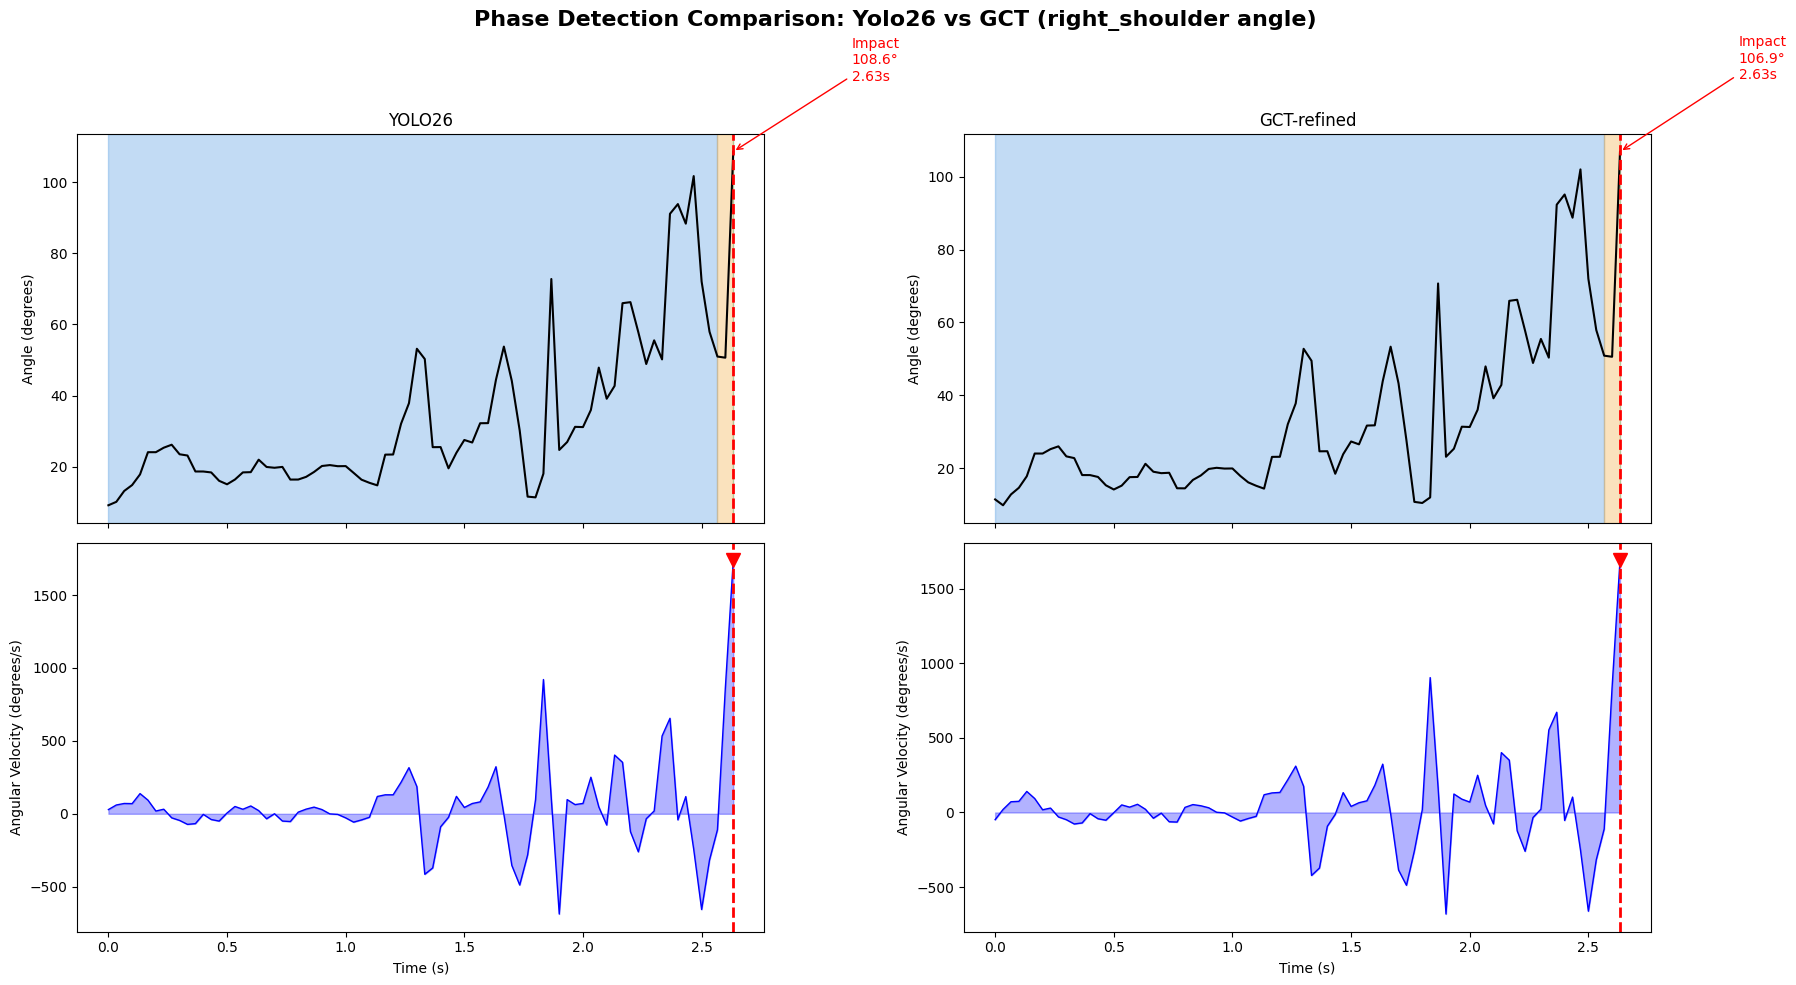

Impact frame: YOLO26=79 (t=2.63s), GCT=79 (t=2.63s)
Peak vel: YOLO26=1737.21 deg/s, GCT=1689.50 deg/s


In [45]:

# ============================================================
# Phase detection comparison: Yolo26 vs GCT
# ============================================================

def calc_angvel(angles, vid_fps):
    dt = 1.0 / vid_fps
    n = len(angles)
    vel = [(angles[1] - angles[0]) / dt if n>1 else 0.0]  # Forward difference for first frame
    for i in range(1, n-1):
        v = (angles[i+1] - angles[i-1]) / (2*dt)  # Central difference
        vel.append(v)
    if n > 1:
        vel.append((angles[-1] - angles[-2]) / dt)  # Backward difference for last frame
    return vel

def detect_phase(angles, angvel, vid_fps, thr = 0.2):
    av = np.abs(angvel)
    imp = int(np.argmax(av)) # Impact frame = max angular velocity
    pk = av[imp]  # Peak angular velocity at impact
    if pk < 1e-6: return {'impact': {'frame': 0, 'time': 0, 'angle': 0, 'peak_vel': 0}}  # No movement case
    th = pk * thr  # Threshold for phase detection
    acc = 0
    for i in range(imp-1,-1,-1):
        if av[i] < th:
            acc = i; break
    fe = len(angles)-1
    for i in range(imp+1, len(angles)):
        if av[i] < th:
            fe = i; break
    return {
        'preparation': {'start_time': 0, 'end_time': acc / vid_fps},
        'acceleration': {'start_time': acc / vid_fps, 'end_time': imp / vid_fps},
        'impact': {'frame': imp, 'time': imp / vid_fps, 'angle': float(angles[imp]), 'peak_vel': float(angvel[imp])},
        'follow_through': {'start_time': imp / vid_fps, 'end_time': fe / vid_fps}
    }
    
pj = 'right_shoulder'
y_v = calc_angvel(yolo_angles[pj], eval_fps)
g_v = calc_angvel(gct_angles[pj], eval_fps)
y_ph = detect_phase(np.array(yolo_angles[pj]), np.array(y_v), eval_fps)
g_ph = detect_phase(np.array(gct_angles[pj]), np.array(g_v), eval_fps)

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex='col')
fig.suptitle(f'Phase Detection Comparison: Yolo26 vs GCT ({pj} angle)', fontsize=16, fontweight='bold')

for col, (title, ang, vel, ph) in enumerate([
    ('YOLO26', yolo_angles[pj], y_v, y_ph),
    ('GCT-refined', gct_angles[pj], g_v, g_ph)]):
    ax = axes[0, col]
    for pn, clr in [('preparation', '#378ADD'), ('acceleration', '#EF9F27'), ('follow_through', '#1D9E75')]:
        if pn in ph: ax.axvspan(ph[pn]['start_time'], ph[pn]['end_time'], color=clr, alpha=0.3)
        
    ax.plot(eval_timestamps, ang, 'k-', lw=1.5)
    it = ph['impact']['time']
    ia = ph['impact']['angle']
    ax.axvline(x=it, color='red', ls='--', lw=2)
    ax.annotate(f"Impact\n{ia:.1f}°\n{it:.2f}s", xy=(it, ia), xytext=(it+0.5, ia+20),
                arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')
    ax.set_title(title)
    ax.set_ylabel('Angle (degrees)')
    ax2 = axes[1, col]
    ax2.plot(eval_timestamps, vel, 'b-', lw=1)
    ax2.fill_between(eval_timestamps, 0, vel, color='blue', alpha=0.3)
    ax2.axvline(x=it, color='red', ls='--', lw=2)
    pv = ph['impact']['peak_vel']
    ax2.plot(it, pv, 'rv', ms=10)
    ax2.set_ylabel('Angular Velocity (degrees/s)')
    ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

print(f"Impact frame: YOLO26={y_ph['impact']['frame']} (t={y_ph['impact']['time']:.2f}s), GCT={g_ph['impact']['frame']} (t={g_ph['impact']['time']:.2f}s)")
print(f"Peak vel: YOLO26={y_ph['impact']['peak_vel']:.2f} deg/s, GCT={g_ph['impact']['peak_vel']:.2f} deg/s")
